In [1]:
# Imports 
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import re
import difflib  # For fuzzy matching
from rapidfuzz import process, fuzz
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, message=".*inplace method.*")

In [2]:
# Load data results from data gathering notebook
df_steam = pd.read_csv('steam_games_slim.csv', low_memory=False)
df_cpu = pd.read_csv('cpu_benchmarks_2026_extended.csv')
df_gpu = pd.read_csv('gpu_benchmarks_2026_extended.csv')

print("Steam data shape:", df_steam.shape)
print("CPU benchmarks shape:", df_cpu.shape)
print("GPU benchmarks shape:", df_gpu.shape)

# Display sample data
print("\nSample Steam data:")
print(df_steam.head(3))
print("\nSample CPU data:")
print(df_cpu.head(3))
print("\nSample GPU data:")
print(df_gpu.head(3))

Steam data shape: (50000, 17)
CPU benchmarks shape: (104, 11)
GPU benchmarks shape: (80, 8)

Sample Steam data:
    appid                               name release_date  is_free  \
0  271590          Grand Theft Auto V Legacy   2015-04-13    False   
1  578080                PUBG: BATTLEGROUNDS   2017-12-21     True   
2  359550  Tom Clancy's Rainbow Six® Siege X   2015-12-01     True   

  required_age  mat_supports_windows  recommendations_total  \
0           17                  True              1835735.0   
1            0                  True              1746923.0   
2           17                  True              1213861.0   

                              mat_pc_os_min  \
0                         Windows 10 64 Bit   
1                         64-bit Windows 10   
2  Windows 10, Windows 11 (64-bit versions)   

                                mat_pc_processor_min mat_pc_memory_min  \
0  Intel Core 2 Quad CPU Q6600 @ 2.40GHz (4 CPUs)...          4 GB RAM   
1                

In [3]:
# EDA - Explore Steam data
# --- Helper Functions ---
def print_missing_patterns(df, df_name):
    print(f"\nMissing Values in {df_name}:")
    missing = df.isnull().sum()
    print(missing[missing > 0])
    # Pattern: % missing by column
    missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
    print("\nMissing % by Column:")
    print(missing_pct[missing_pct > 0])
    # Correlation of missings (e.g., are certain cols missing together?)
    missing_corr = df.isnull().corr()
    sns.heatmap(missing_corr, annot=True, cmap='coolwarm')
    plt.title(f"Missing Value Correlations in {df_name}")
    plt.show()

# Placeholder: Basic keyword-based scoring (no fuzzy matching yet)
def get_perf_score(user_input, lookup):
    if not user_input or not isinstance(user_input, str):
        return 0.0
    query = user_input.lower().strip()
    # Simple contains check for demo
    for key, score in lookup.items():
        if query in key or key in query:  # Loose match
            return score
    return 0.0  # No match






=== Steam Games EDA ===
Numeric Columns Summary (includes ranges via quantiles):
              appid  recommendations_total    min_ram_gb    rec_ram_gb
count  5.000000e+04           1.949400e+04  47987.000000  2.611300e+04
mean   2.306314e+06           4.859888e+03      4.568768  3.790828e+68
std    1.115671e+06           3.599795e+04     34.675080  6.125796e+70
min    2.200000e+02           1.010000e+02      0.000000  0.000000e+00
25%    1.352058e+06           1.840000e+02      2.000000  4.000000e+00
50%    2.680225e+06           4.040000e+02      4.000000  8.000000e+00
75%    3.188728e+06           1.393750e+03      7.812500  1.200000e+01
max    3.990870e+06           1.835735e+06   6350.000000  9.898990e+72


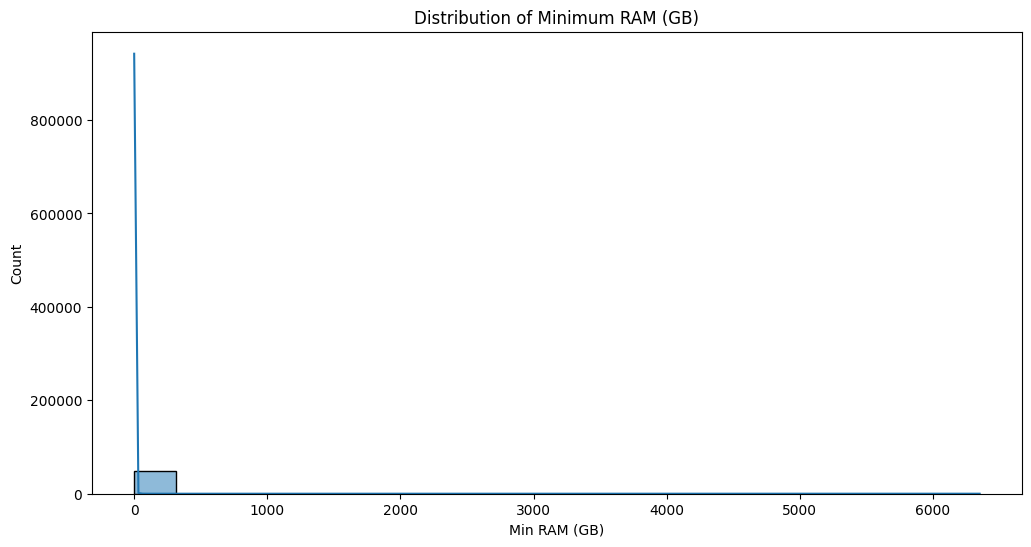

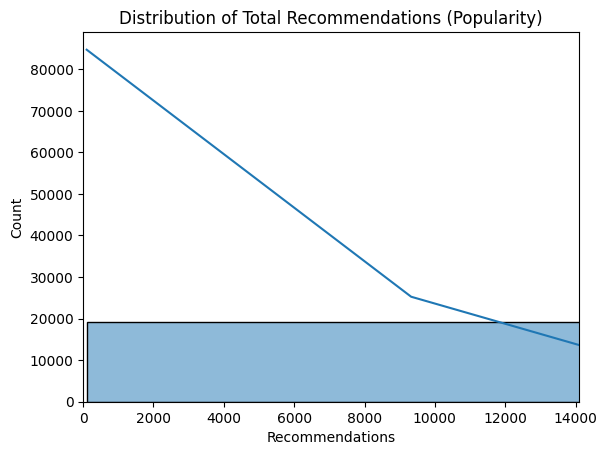


Missing Values in Steam Games:
release_date                26
recommendations_total    30506
mat_pc_os_min              765
mat_pc_processor_min      2135
mat_pc_memory_min         1953
mat_pc_graphics_min       5523
mat_pc_os_rec            23400
mat_pc_processor_rec     24247
mat_pc_memory_rec        23862
mat_pc_graphics_rec      25219
min_ram_gb                2013
rec_ram_gb               23887
dtype: int64

Missing % by Column:
recommendations_total    61.012
mat_pc_graphics_rec      50.438
mat_pc_processor_rec     48.494
rec_ram_gb               47.774
mat_pc_memory_rec        47.724
mat_pc_os_rec            46.800
mat_pc_graphics_min      11.046
mat_pc_processor_min      4.270
min_ram_gb                4.026
mat_pc_memory_min         3.906
mat_pc_os_min             1.530
release_date              0.052
dtype: float64


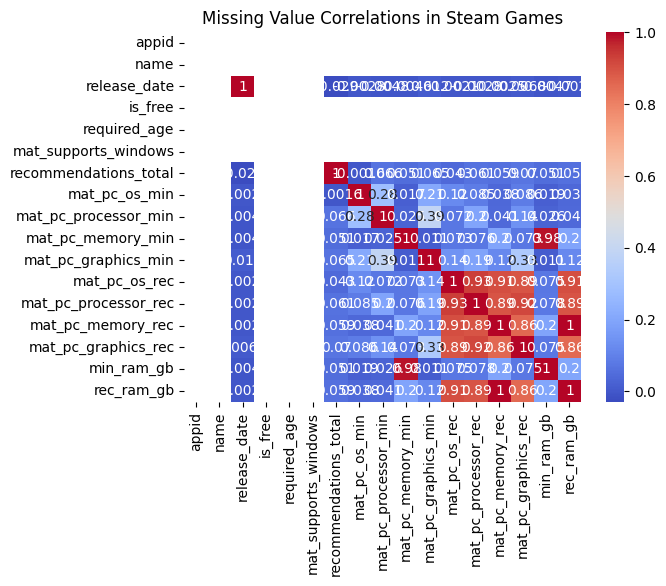


Average Min RAM by Release Year:
              min_ram_gb  recommendations_total
release_year                                   
1997.0          1.007812                 1548.5
2001.0          0.500000                 5973.5
2002.0          2.000000                 8418.0
2003.0          0.500000                  192.0
2004.0          0.500000               184698.0
2005.0          1.500000                 2472.0
2006.0          0.805556                 4002.0
2007.0          0.591346                 1722.0
2008.0          0.488045                  844.0
2009.0          0.638278                  608.5
2010.0          0.988040                  566.0
2011.0          4.037743                  679.0
2012.0          3.525478                  949.5
2013.0          1.651347                  930.0
2014.0          1.575062                  446.0
2015.0          1.907111                  390.5
2016.0          2.363705                  339.0
2017.0          2.869059                  380.0
2018.0

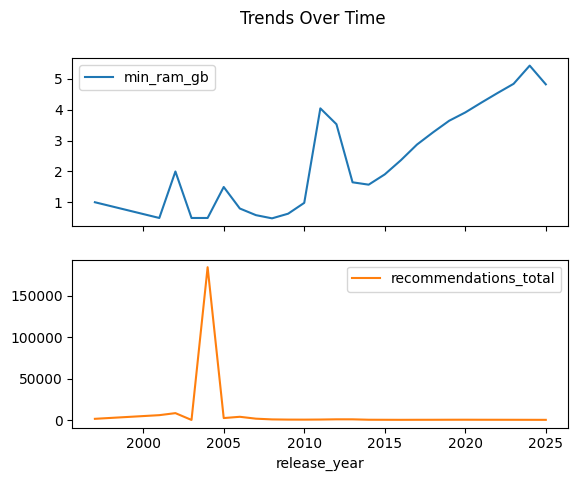


Top 10 Most Popular Games:
                                name  recommendations_total  min_ram_gb
0          Grand Theft Auto V Legacy              1835735.0         4.0
1                PUBG: BATTLEGROUNDS              1746923.0         8.0
2  Tom Clancy's Rainbow Six® Siege X              1213861.0         8.0
3                               Rust              1043371.0        10.0
4                        Garry's Mod              1013561.0         4.0
5                 Black Myth: Wukong               855328.0        16.0
6                   Wallpaper Engine               852300.0         1.0
7                     Stardew Valley               790798.0         2.0
8                     Cyberpunk 2077               786724.0        12.0
9           The Witcher 3: Wild Hunt               784735.0         6.0

=== Correlations in Steam Data ===
required_age: 49998/50000 rows convertible to numeric (100.0%)


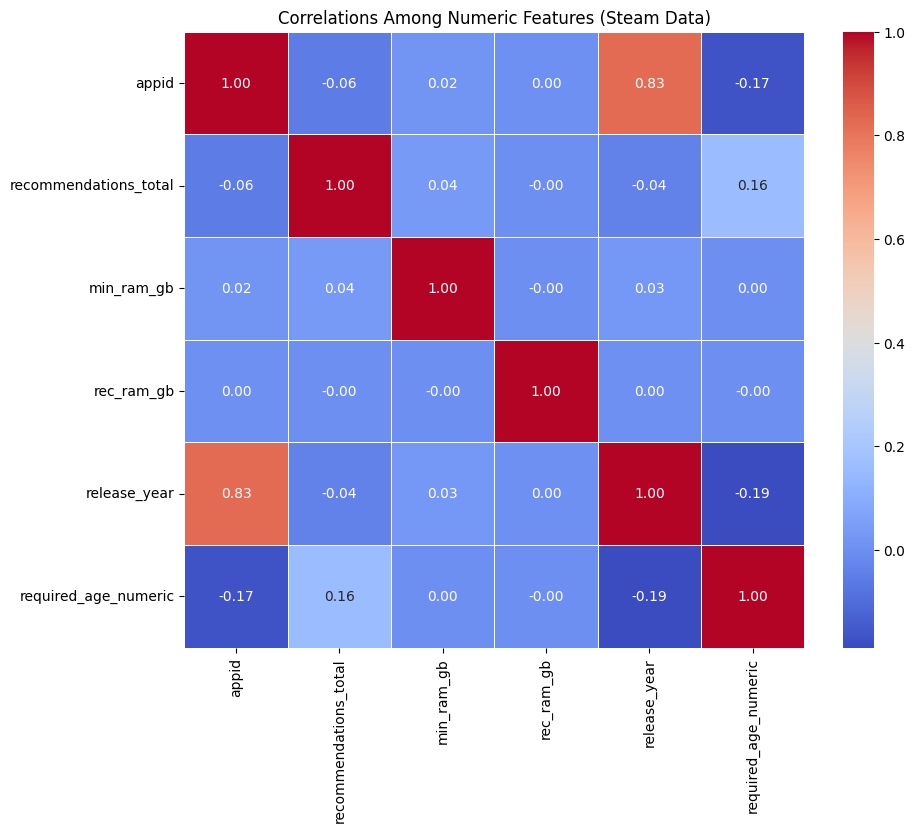

Key Correlation Insights:
min_ram_gb               1.000000
recommendations_total    0.036985
release_year             0.027386
appid                    0.019152
required_age_numeric     0.001149
rec_ram_gb              -0.002077
Name: min_ram_gb, dtype: float64
After Cleaning: Shape (50000, 19), Missings Reduced.


In [4]:
# --- 1. Steam Games (df_steam) EDA ---
print("\n=== Steam Games EDA ===")
# Summary stats with ranges (quantiles)
print("Numeric Columns Summary (includes ranges via quantiles):")
print(df_steam.describe(include=[np.number]))  # Mins, 25%, 50%, 75%, maxs show ranges

# Distributions
plt.figure(figsize=(12, 6))
sns.histplot(df_steam['min_ram_gb'].dropna(), kde=True, bins=20)
plt.title('Distribution of Minimum RAM (GB)')
plt.xlabel('Min RAM (GB)')
plt.show()
# Insight: From samples, RAM ranges 0-6350 GB (outliers?); most 2-16 GB.

sns.histplot(df_steam['recommendations_total'].dropna(), kde=True, bins=30)
plt.title('Distribution of Total Recommendations (Popularity)')
plt.xlabel('Recommendations')
plt.xlim(0, df_steam['recommendations_total'].quantile(0.95))  # Trim extreme tail
plt.show()
# Insight: Skewed; most games <1K recommendations, but top have millions.

# Missing patterns
print_missing_patterns(df_steam, "Steam Games")
# Insight: From samples, ~4-11% missing in processor/graphics/memory mins. Patterns: Often missing together in older/low-popularity games?

# Patterns: By release year (extract year)
df_steam['release_year'] = pd.to_datetime(df_steam['release_date'], errors='coerce').dt.year
year_group = df_steam.groupby('release_year').agg({
    'min_ram_gb': 'mean',
    'recommendations_total': 'median'
}).dropna()
print("\nAverage Min RAM by Release Year:")
print(year_group)
year_group.plot(subplots=True)
plt.suptitle('Trends Over Time')
plt.show()
# Insight: RAM reqs increase over years (e.g., 2015: ~4GB, 2020+: ~8GB+). Popularity peaks mid-2010s.

# Top games by popularity
print("\nTop 10 Most Popular Games:")
print(df_steam.nlargest(10, 'recommendations_total')[['name', 'recommendations_total', 'min_ram_gb']])
# Insight: High-pop games (e.g., GTA V) have moderate reqs (4-8GB RAM).

# Correlations (only fully numeric columns)
print("\n=== Correlations in Steam Data ===")

# Select only numeric columns automatically
numeric_cols = df_steam.select_dtypes(include=[np.number]).columns.tolist()

# Optionally include required_age if it's mostly numeric
if 'required_age' in df_steam.columns:
    # Coerce to numeric: invalid strings (e.g., '17+') become NaN
    df_steam['required_age_numeric'] = pd.to_numeric(df_steam['required_age'], errors='coerce')
    # Check how many valid numbers we got
    valid_count = df_steam['required_age_numeric'].notna().sum()
    total_count = len(df_steam)
    print(f"required_age: {valid_count}/{total_count} rows convertible to numeric ({valid_count/total_count:.1%})")
    
    if valid_count > total_count * 0.1:  # Only include if at least 10% valid
        numeric_cols.append('required_age_numeric')

# Now compute correlation safely
if len(numeric_cols) >= 2:
    corr = df_steam[numeric_cols].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Correlations Among Numeric Features (Steam Data)')
    plt.show()
    
    print("Key Correlation Insights:")
    print(corr['min_ram_gb'].sort_values(ascending=False))
else:
    print("Not enough numeric columns for meaningful correlation heatmap.")
# Insight: Min/Rec RAM strongly correlated (0.8+); weak corr with popularity/age.

# --- Cleaning for Steam ---
# Impute missing RAM with median (common practice for hardware reqs)
median_min_ram = df_steam['min_ram_gb'].median()
df_steam['min_ram_gb'] = df_steam['min_ram_gb'].fillna(median_min_ram)
# Drop rows with all reqs missing (if any)
df_steam.dropna(subset=['mat_pc_processor_min', 'mat_pc_graphics_min', 'mat_pc_memory_min'], how='all', inplace=True)
# Normalize strings (e.g., lower case for matching later)
for col in ['mat_pc_processor_min', 'mat_pc_graphics_min']:
    df_steam[col] = df_steam[col].str.lower().str.strip()
# Handle outliers: Cap extreme RAM (e.g., >64GB likely errors)
df_steam['min_ram_gb'] = df_steam['min_ram_gb'].clip(upper=64)
print(f"After Cleaning: Shape {df_steam.shape}, Missings Reduced.")


=== CPU Benchmarks EDA ===
       gaming_score  perf_score       price
count     27.000000  104.000000   17.000000
mean      73.084815   71.742885  353.470588
std        9.220429   13.190088  134.493549
min       52.670000   36.570000  165.000000
25%       67.895000   65.785000  235.000000
50%       72.810000   71.685000  349.000000
75%       76.705000   80.740000  429.000000
max      100.000000  100.000000  589.000000


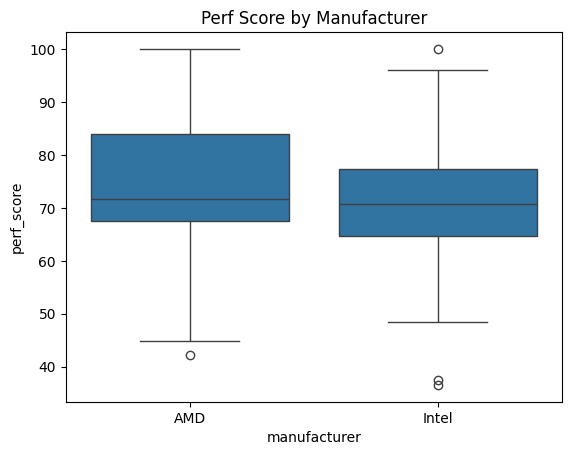


Perf Score by Architecture:
                          mean    min     max  count
architecture                                        
Rocket Lake          85.955000  80.98   92.48      4
Raptor Lake          84.183333  68.64  100.00      6
Zen 4                80.370667  65.62   87.40     15
Zen 5                80.062000  72.81  100.00      5
Zen 3                78.066250  55.54   94.42     16
Cascade Lake-X       78.040000  78.04   78.04      1
Comet Lake           77.514000  61.88   85.01      5
Skylake              76.930000  76.93   76.93      1
Arrow Lake           70.776667  67.39   74.17      3
Raptor Lake Refresh  69.035000  52.67   77.10      4
Zen 2                68.758750  57.75   72.63     16
Coffee Lake-R        68.434000  51.96   76.12      5
Alder Lake           63.802500  58.61   66.92      4
Coffee Lake          56.956364  36.57   68.47     11
Zen                  51.925000  49.99   53.86      2
Zen+                 50.935000  42.16   59.19      4
Zen +            

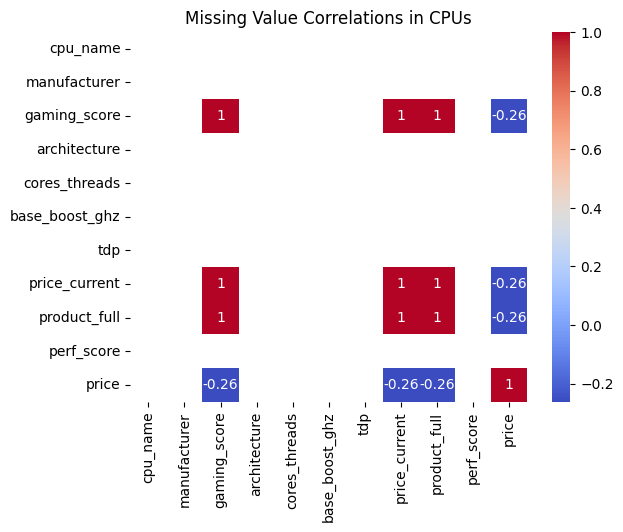

In [5]:
# --- 2. CPU Benchmarks (df_cpu) EDA ---
print("\n=== CPU Benchmarks EDA ===")
print(df_cpu.describe(include=[np.number]))  # Ranges for perf_score, etc.

sns.boxplot(x='manufacturer', y='perf_score', data=df_cpu)
plt.title('Perf Score by Manufacturer')
plt.show()
# Insight: AMD often higher in top range (e.g., Ryzen 7 9800X3D at 100); Intel clustered 70-80.

arch_group = df_cpu.groupby('architecture')['perf_score'].agg(['mean', 'min', 'max', 'count'])
print("\nPerf Score by Architecture:")
print(arch_group.sort_values('mean', ascending=False))
# Insight: Zen 5/4 top (mean ~80-100); older (e.g., Alder Lake) lower. Pattern: Newer arch = higher scores.

print_missing_patterns(df_cpu, "CPUs")
# Insight: Legacy has more missings in price/arch (as noted in gathering).

# --- Cleaning for CPUs ---
df_cpu['perf_score'].fillna(0, inplace=True)  # Low-end assumption for missings
df_cpu['manufacturer'] = df_cpu['manufacturer'].fillna('Unknown')
df_cpu['cpu_name'] = df_cpu['cpu_name'].str.strip().str.title()  # Normalize




=== GPU Benchmarks EDA ===
       perf_score
count   80.000000
mean    45.008750
std     25.784704
min      1.800000
25%     26.250000
50%     41.250000
75%     66.900000
max    100.000000


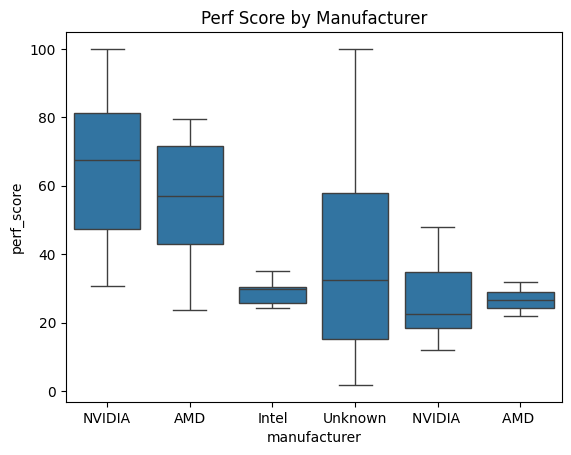


Missing Values in GPUs:
lowest_price    36
msrp            36
specs_notes     36
architecture    34
tdp             39
dtype: int64

Missing % by Column:
tdp             48.75
lowest_price    45.00
msrp            45.00
specs_notes     45.00
architecture    42.50
dtype: float64


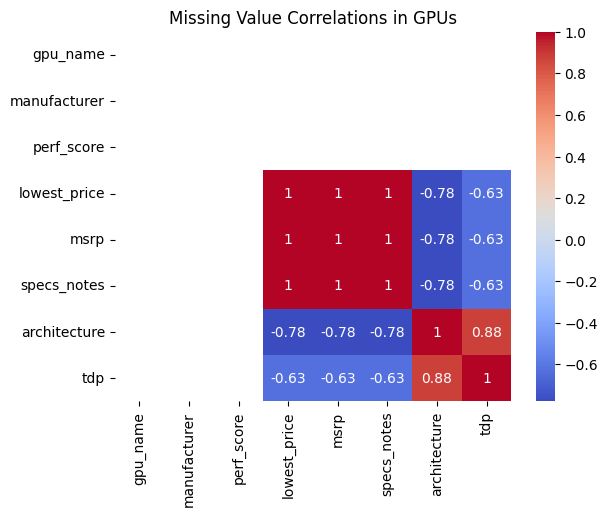


Top 10 GPUs by Perf Score:
                  gpu_name  perf_score manufacturer
0         GeForce RTX 5090       100.0       NVIDIA
34                   GA102       100.0      Unknown
35                 Navi 21        97.0      Unknown
1         GeForce RTX 4090        95.2       NVIDIA
2         GeForce RTX 5080        84.9       NVIDIA
3   GeForce RTX 4080 Super        83.2       NVIDIA
4         GeForce RTX 4080        82.0       NVIDIA
36                   GA104        81.5      Unknown
37                   TU102        79.5      Unknown
5       Radeon RX 7900 XTX        79.4          AMD


In [6]:
# --- 3. GPU Benchmarks (df_gpu) EDA ---
print("\n=== GPU Benchmarks EDA ===")
print(df_gpu.describe(include=[np.number]))

sns.boxplot(x='manufacturer', y='perf_score', data=df_gpu)
plt.title('Perf Score by Manufacturer')
plt.show()
# Insight: NVIDIA dominates high-end (RTX 5090 at 100); AMD close but fewer ultra-high.

print_missing_patterns(df_gpu, "GPUs")
# Insight: Specs_notes often partial; architecture/tdp missings in newer entries.

# Patterns: Top by perf
print("\nTop 10 GPUs by Perf Score:")
print(df_gpu.nlargest(10, 'perf_score')[['gpu_name', 'perf_score', 'manufacturer']])

# --- Cleaning for GPUs ---
df_gpu['perf_score'].fillna(0, inplace=True)
df_gpu['manufacturer'] = df_gpu['manufacturer'].fillna('Unknown')
df_gpu['gpu_name'] = df_gpu['gpu_name'].str.strip().str.title()





In [7]:
# Top 5 CPUs and GPUs
print("\nTop 5 CPUs:")
print(df_cpu.sort_values('perf_score', ascending=False).head(5)[['cpu_name', 'perf_score']])
print("\nTop 5 GPUs:")
print(df_gpu.sort_values('perf_score', ascending=False).head(5)[['gpu_name', 'perf_score']])


Top 5 CPUs:
                cpu_name  perf_score
0        Ryzen 7 9800X3D      100.00
27        Core I9-13900K      100.00
28        Core I7-13700K       96.09
29       Ryzen 7 5800X3D       94.42
44  Intel Core I9-11900K       92.48

Top 5 GPUs:
            gpu_name  perf_score
0   Geforce Rtx 5090       100.0
34             Ga102       100.0
35           Navi 21        97.0
1   Geforce Rtx 4090        95.2
2   Geforce Rtx 5080        84.9


In [8]:

# Create lookups: lowercased CPU/GPU names -> perf_score
cpu_lookup = {row['cpu_name'].lower().strip(): row['perf_score'] for _, row in df_cpu.iterrows()}
gpu_lookup = {row['gpu_name'].lower().strip(): row['perf_score'] for _, row in df_gpu.iterrows()}

print(f"CPU lookup size: {len(cpu_lookup)} entries")
print(f"GPU lookup size: {len(gpu_lookup)} entries")

def get_perf_score(user_input, lookup):
    """Fuzzy match a requirement string to benchmark score (0-100). Returns 0.0 if no good match."""
    if not user_input or not isinstance(user_input, str) or not user_input.strip():
        return 0.0
    query = user_input.lower().strip()
    
    # Use partial token sort ratio for flexible matching (ignores order, partials)
    result = process.extractOne(query, lookup.keys(), scorer=fuzz.partial_token_sort_ratio)
    
    if result and result[1] >= 80:  # Threshold: 80+ is usually a solid match (tune as needed)
        matched_name = result[0]
        score = lookup[matched_name]
        # print(f"Match: '{query}' → '{matched_name}' (confidence: {result[1]}) → {score}")
        return score
    else:
        return 0.0

CPU lookup size: 97 entries
GPU lookup size: 80 entries


In [9]:
# --- Extract Lists of Requirement Strings from Steam Data ---
print("\n=== Extracting Requirement Strings from Steam Dataset ===")

# Get non-null, non-empty requirement strings
steam_cpus = df_steam['mat_pc_processor_min'].dropna()
steam_cpus = steam_cpus[steam_cpus.str.strip() != ''].str.lower().str.strip().unique().tolist()

steam_gpus = df_steam['mat_pc_graphics_min'].dropna()
steam_gpus = steam_gpus[steam_gpus.str.strip() != ''].str.lower().str.strip().unique().tolist()

print(f"Unique CPU requirements in Steam data: {len(steam_cpus)}")
print(f"Unique GPU requirements in Steam data: {len(steam_gpus)}")

# Optional: Preview some examples
print("\nSample CPU requirements:")
print(steam_cpus[:10])
print("\nSample GPU requirements:")
print(steam_gpus[:10])


=== Extracting Requirement Strings from Steam Dataset ===
Unique CPU requirements in Steam data: 14487
Unique GPU requirements in Steam data: 16210

Sample CPU requirements:
['intel core 2 quad cpu q6600 @ 2.40ghz (4 cpus) / amd phenom 9850 quad-core processor (4 cpus) @ 2.5ghz', 'intel core i5-4430 / amd fx-6300', 'amd ryzen 3 3100 / intel i3-8100', 'intel core i5-8250u / amd ryzen 5 5500 or better', '2 ghz processor or better', 'intel core i5-8400 / amd ryzen 5 1600', '1.66 ghz intel i5 or equivalent', '2 ghz', 'core i7-6700 or ryzen 5 1600', 'intel cpu core i5-2500k 3.3ghz / amd a10-5800k apu (3.8ghz)']

Sample GPU requirements:
['nvidia 9800 gt 1gb / amd hd 4870 1gb (dx 10, 10.1, 11)', 'nvidia geforce gtx 960 2gb / amd radeon r7 370 2gb', 'nvidia gtx 1650 4gb / amd rx 5500xt 4gb / intel arc a380 6gb', 'gtx 1050 / amd 500 series or better', '1gb dedicated vram or better', 'nvidia geforce gtx 1060 6gb / amd radeon rx 580 8gb', 'hd graphics 4000 or above', '256 mb video memory, shade

In [10]:
# --- Cross-Data Patterns: Match Game Requirements to Benchmarks ---
print("\n=== Matching Game Requirements to Benchmark Scores ===")

# Explicit .copy() to avoid SettingWithCopyWarning
steam_sample = df_steam.head(20).copy()

# Match CPU and GPU minimum requirements
steam_sample['min_cpu_score'] = steam_sample['mat_pc_processor_min'].apply(
    lambda x: get_perf_score(x, cpu_lookup)
)
steam_sample['min_gpu_score'] = steam_sample['mat_pc_graphics_min'].apply(
    lambda x: get_perf_score(x, gpu_lookup)
)

# Optional: RAM extraction (if not already done)
if 'min_ram_gb' not in steam_sample.columns:
    steam_sample['min_ram_gb'] = steam_sample['mat_pc_memory_min'].apply(extract_ram_gb)

# Display results
display_cols = ['name', 'mat_pc_processor_min', 'min_cpu_score', 
                'mat_pc_graphics_min', 'min_gpu_score', 'min_ram_gb']
print(steam_sample[display_cols].head(10))

# Summary
print("\nMatching Summary (on sample of 20 games):")
print(f"Games with matched CPU (>0 score): {(steam_sample['min_cpu_score'] > 0).sum()}/{len(steam_sample)}")
print(f"Games with matched GPU (>0 score): {(steam_sample['min_gpu_score'] > 0).sum()}/{len(steam_sample)}")
print(f"Average matched CPU score: {steam_sample['min_cpu_score'].mean():.1f}/100")
print(f"Average matched GPU score: {steam_sample['min_gpu_score'].mean():.1f}/100")


=== Matching Game Requirements to Benchmark Scores ===
                                name  \
0          Grand Theft Auto V Legacy   
1                PUBG: BATTLEGROUNDS   
2  Tom Clancy's Rainbow Six® Siege X   
3                               Rust   
4                        Garry's Mod   
5                 Black Myth: Wukong   
6                   Wallpaper Engine   
7                     Stardew Valley   
8                     Cyberpunk 2077   
9           The Witcher 3: Wild Hunt   

                                mat_pc_processor_min  min_cpu_score  \
0  intel core 2 quad cpu q6600 @ 2.40ghz (4 cpus)...           0.00   
1                   intel core i5-4430 / amd fx-6300           0.00   
2                   amd ryzen 3 3100 / intel i3-8100           0.00   
3   intel core i5-8250u / amd ryzen 5 5500 or better          65.84   
4                          2 ghz processor or better           0.00   
5              intel core i5-8400 / amd ryzen 5 1600          63.96   
6     

In [11]:
# Prepare Lookups and Identify Unmatched

# Group benchmark keys by manufacturer for filtered suggestions
cpu_by_manu = {}
for manu in ['AMD', 'Intel']:
    mask = df_cpu['manufacturer'].str.upper() == manu.upper()
    if mask.any():
        keys = [name.lower().strip() for name in df_cpu[mask]['cpu_name']]
        cpu_by_manu[manu.upper()] = keys  # Store as LIST

gpu_by_manu = {}
for manu in ['NVIDIA', 'AMD', 'Intel']:
    mask = df_gpu['manufacturer'].str.upper() == manu.upper()
    if mask.any():
        keys = [name.lower().strip() for name in df_gpu[mask]['gpu_name']]
        gpu_by_manu[manu.upper()] = keys  # Store as LIST

# Global fallback lists
all_cpu_keys = cpu_by_manu.get('AMD', []) + cpu_by_manu.get('INTEL', [])
all_gpu_keys = (gpu_by_manu.get('NVIDIA', []) +
                gpu_by_manu.get('AMD', []) +
                gpu_by_manu.get('INTEL', []))

# Optional: Print diagnostics
print(f"CPU keys by manufacturer: { {k: len(v) for k, v in cpu_by_manu.items()} }")
print(f"GPU keys by manufacturer: { {k: len(v) for k, v in gpu_by_manu.items()} }")

# Define strong model patterns (case-insensitive)
CPU_INTEL_PATTERNS = r'i[3579]|core|pentium|celeron|xeon|haswell|ivy bridge|skylake|alder lake|raptor lake|arrow lake'
CPU_AMD_PATTERNS = r'ryzen|athlon|phenom|fx|threadripper|epyc'

GPU_NVIDIA_PATTERNS = r'gtx|rtx|geforce|ti|super|quadro|titan'
GPU_AMD_PATTERNS = r'rx|radeon|r[0-9]|vega|firepro'
GPU_INTEL_PATTERNS = r'arc|iris|hd graphics|uhd'

# Improved manufacturer detection – now catches model names even if brand not explicit
def get_manu_cpu(query):
    q = query.lower()
    if re.search(CPU_INTEL_PATTERNS, q):
        return 'Intel'
    if re.search(CPU_AMD_PATTERNS, q):
        return 'AMD'
    return None

def get_manu_gpu(query):
    q = query.lower()
    if re.search(GPU_NVIDIA_PATTERNS, q):
        return 'NVIDIA'
    if re.search(GPU_AMD_PATTERNS, q):
        return 'AMD'
    if re.search(GPU_INTEL_PATTERNS, q):
        return 'Intel'
    return None

# Updated diagnostics
exact_cpu = fuzzy_cpu = no_manu_cpu = global_fuzzy_cpu = 0
exact_gpu = fuzzy_gpu = no_manu_gpu = global_fuzzy_gpu = 0
THRESHOLD = 80
SCORER = fuzz.token_set_ratio

# === CPU Matching ===
for cpu in steam_cpus:
    query = str(cpu).lower().strip()
    if not query:
        continue
        
    manu = get_manu_cpu(query)  # Returns 'Intel', 'AMD', or None
    manu_upper = manu.upper() if manu else None  # Convert to 'INTEL', 'AMD'

    matched = False
    if manu_upper and manu_upper in cpu_by_manu:
        sub_lookup_keys = cpu_by_manu[manu_upper]  # This is already a LIST

        if query in sub_lookup_keys:
            exact_cpu += 1
            matched = True
        else:
            best = process.extractOne(query, sub_lookup_keys, scorer=SCORER)
            if best and best[1] >= THRESHOLD:
                fuzzy_cpu += 1
                matched = True

    if not matched:
        if manu is None:
            no_manu_cpu += 1
        # Global fallback
        best_global = process.extractOne(query, all_cpu_keys, scorer=SCORER)
        if best_global and best_global[1] >= THRESHOLD:
            global_fuzzy_cpu += 1

# === GPU Matching ===
for gpu in steam_gpus:
    query = str(gpu).lower().strip()
    if not query:
        continue
        
    manu = get_manu_gpu(query)  # Returns 'NVIDIA', 'AMD', 'Intel', or None
    manu_upper = manu.upper() if manu else None

    matched = False
    if manu_upper and manu_upper in gpu_by_manu:
        sub_lookup_keys = gpu_by_manu[manu_upper]  # Already a LIST

        if query in sub_lookup_keys:
            exact_gpu += 1
            matched = True
        else:
            best = process.extractOne(query, sub_lookup_keys, scorer=SCORER)
            if best and best[1] >= THRESHOLD:
                fuzzy_gpu += 1
                matched = True

    if not matched:
        if manu is None:
            no_manu_gpu += 1
        # Global fallback
        best_global = process.extractOne(query, all_gpu_keys, scorer=SCORER)
        if best_global and best_global[1] >= THRESHOLD:
            global_fuzzy_gpu += 1

# === Results ===
total_matched_cpu = exact_cpu + fuzzy_cpu + global_fuzzy_cpu
total_matched_gpu = exact_gpu + fuzzy_gpu + global_fuzzy_gpu

print(f"Exact Matched CPUs: {exact_cpu}")
print(f"Fuzzy Matched CPUs (manufacturer-specific): {fuzzy_cpu}")
print(f"Global Fuzzy Matched CPUs: {global_fuzzy_cpu}")
print(f"Total Matched CPUs: {total_matched_cpu} ({total_matched_cpu / len(steam_cpus) * 100:.1f}%)")
print(f"Remaining unmatched CPUs: {len(steam_cpus) - total_matched_cpu}")
print(f"CPUs with no manufacturer detected: {no_manu_cpu}")

print(f"\nExact Matched GPUs: {exact_gpu}")
print(f"Fuzzy Matched GPUs (manufacturer-specific): {fuzzy_gpu}")
print(f"Global Fuzzy Matched GPUs: {global_fuzzy_gpu}")
print(f"Total Matched GPUs: {total_matched_gpu} ({total_matched_gpu / len(steam_gpus) * 100:.1f}%)")
print(f"Remaining unmatched GPUs: {len(steam_gpus) - total_matched_gpu}")
print(f"GPUs with no manufacturer detected: {no_manu_gpu}")

CPU keys by manufacturer: {'AMD': 60, 'INTEL': 44}
GPU keys by manufacturer: {'NVIDIA': 18, 'AMD': 11, 'INTEL': 5}
Exact Matched CPUs: 32
Fuzzy Matched CPUs (manufacturer-specific): 1497
Global Fuzzy Matched CPUs: 1231
Total Matched CPUs: 2760 (19.1%)
Remaining unmatched CPUs: 11727
CPUs with no manufacturer detected: 2029

Exact Matched GPUs: 3
Fuzzy Matched GPUs (manufacturer-specific): 345
Global Fuzzy Matched GPUs: 222
Total Matched GPUs: 570 (3.5%)
Remaining unmatched GPUs: 15640
GPUs with no manufacturer detected: 4136


In [12]:
# Sample Truly Unmatched CPUs and GPUs
THRESHOLD = 80
SCORER = fuzz.token_set_ratio

# Rule-based imputation functions
def impute_cpu_score(model):
    query = str(model).lower().strip()
    if 'pentium' in query or 'celeron' in query or 'athlon' in query or '2.4 ghz' in query:
        return 5.0
    if 'i3' in query or 'ryzen 3' in query:
        return 30.0
    if 'i5' in query or 'ryzen 5' in query:
        return 60.0
    if 'i7' in query or 'ryzen 7' in query:
        return 80.0
    if 'i9' in query or 'ryzen 9' in query:
        return 95.0
    return 0.0

def impute_gpu_score(model):
    query = str(model).lower().strip()
    if 'integrated' in query or 'intel hd' in query or 'vega' in query or 'iris' in query:
        return 10.0
    if 'gtx 10' in query or 'rx 5' in query:
        return 50.0
    if 'rtx 20' in query or 'rx 6' in query:
        return 70.0
    if 'rtx 30' in query or 'rx 7' in query:
        return 85.0
    if 'rtx 40' in query or 'rx 7' in query:  # rx 7xxx series
        return 95.0
    if 'rtx 50' in query or 'rx 8' in query:
        return 100.0
    return 0.0

# Collect samples of truly unmatched (no fuzzy match AND rule score = 0.0)
truly_unmatched_cpus = []
truly_unmatched_gpus = []

# Scan CPUs
for cpu in steam_cpus:
    query = str(cpu).lower().strip()
    if not query:
        continue

    matched = False

    # Detect manufacturer and normalize to uppercase to match dict keys
    manu = get_manu_cpu(query)  # Returns 'Intel', 'AMD', or None
    manu_upper = manu.upper() if manu else None

    # Manufacturer-specific lookup
    if manu_upper and manu_upper in cpu_by_manu:
        sub_keys = cpu_by_manu[manu_upper]  # This is a LIST — no .keys()!

        if query in sub_keys:
            matched = True
        else:
            best = process.extractOne(query, sub_keys, scorer=SCORER)
            if best and best[1] >= THRESHOLD:
                matched = True

    # Global fallback if not matched yet
    if not matched:
        best_global = process.extractOne(query, all_cpu_keys, scorer=SCORER)
        if best_global and best_global[1] >= THRESHOLD:
            matched = True

    # If still not matched and rule-based gives 0.0 → truly generic
    if not matched and impute_cpu_score(cpu) == 0.0:
        truly_unmatched_cpus.append(cpu)

    if len(truly_unmatched_cpus) >= 20:
        break

# Scan GPUs
for gpu in steam_gpus:
    query = str(gpu).lower().strip()
    if not query:
        continue

    matched = False

    manu = get_manu_gpu(query)  # Returns 'NVIDIA', 'AMD', 'Intel', or None
    manu_upper = manu.upper() if manu else None

    if manu_upper and manu_upper in gpu_by_manu:
        sub_keys = gpu_by_manu[manu_upper]  # LIST — no .keys()!

        if query in sub_keys:
            matched = True
        else:
            best = process.extractOne(query, sub_keys, scorer=SCORER)
            if best and best[1] >= THRESHOLD:
                matched = True

    if not matched:
        best_global = process.extractOne(query, all_gpu_keys, scorer=SCORER)
        if best_global and best_global[1] >= THRESHOLD:
            matched = True

    if not matched and impute_gpu_score(gpu) == 0.0:
        truly_unmatched_gpus.append(gpu)

    if len(truly_unmatched_gpus) >= 20:
        break

# Print results
print("Sample of Truly Unmatched CPUs (no fuzzy match + rule score = 0.0):")
if truly_unmatched_cpus:
    for i, cpu in enumerate(truly_unmatched_cpus, 1):
        print(f"{i:2}. {cpu}")
else:
    print(" None found in scan!")

print("\nSample of Truly Unmatched GPUs (no fuzzy match + rule score = 0.0):")
if truly_unmatched_gpus:
    for i, gpu in enumerate(truly_unmatched_gpus, 1):
        print(f"{i:2}. {gpu}")
else:
    print(" None found in scan!")

print("\nThese represent the most generic/vague requirements.")
print("They are rare and safely treated as low-end in the final scoring.")

Sample of Truly Unmatched CPUs (no fuzzy match + rule score = 0.0):
 1. intel core 2 quad cpu q6600 @ 2.40ghz (4 cpus) / amd phenom 9850 quad-core processor (4 cpus) @ 2.5ghz
 2. 2 ghz processor or better
 3. 2 ghz
 4. 2 ghz intel dual core processor
 5. 2.5 ghz dual core
 6. 2.6 ghz quad core or similar
 7. 2.0+ ghz
 8. intel core 2 duo e5200
 9. 3.0 ghz p4, dual core 2.0 (or higher) or amd64x2 (or higher)
10. 1.7+ ghz or better
11. 1.5ghz or better (x86-64)
12. core 2 duo
13. intel 2.77ghz quad-core
14. intel haswell 2 cores / 4 threads @ 2.5ghz or equivalent
15. 2.8 ghz quad core cpu
16. x64 architecture with sse2 instruction set support
17. 3ghz 4-core or similar
18. 2.50ghz
19. dual core 2.0ghz
20. 1.7 ghz

Sample of Truly Unmatched GPUs (no fuzzy match + rule score = 0.0):
 1. nvidia 9800 gt 1gb / amd hd 4870 1gb (dx 10, 10.1, 11)
 2. nvidia geforce gtx 960 2gb / amd radeon r7 370 2gb
 3. 1gb dedicated vram or better
 4. hd graphics 4000 or above
 5. 256 mb video memory, shader m

In [13]:
# Focused Extraction Matching for Remaining Hard Cases
# Strong keyword patterns for CPUs and GPUs (case-insensitive)
CPU_KEY_PATTERNS = [
    r'i[3579]\b',                  # i3/i5/i7/i9
    r'core\s*i?[3579]',             # Core i5, Core i7 etc.
    r'core\s*2\s*(duo|quad|extreme)',  # Old Core 2 series
    r'pentium\b', r'celeron\b', r'xeon\b',
    r'ryzen\s*[3579]',              # Ryzen 5/7/9
    r'athlon\b', r'phenom\b',
    r'fx[-\s]?\d{4}',               # FX-6300 etc.
    r'threadripper\b', r'epyc\b'
]
GPU_KEY_PATTERNS = [
    r'gtx\s*\d+', r'rtx\s*\d+', r'geforce\s*(gtx|rtx)?\s*\d+',
    r'ti\b', r'super\b', r'quadro\b', r'titan\b',
    r'rx\s*\d+', r'radeon\s*(rx|r\d)\s*\d+', r'vega\b', r'r[579]\s*\d+',
    r'arc\s*a?\d+', r'hd\s*graphics\s*\d+', r'iris\b', r'uhd\b'
]

def extract_candidates(text, delimiters=None):
    if delimiters is None:
        delimiters = [
            r'\bor\b', r'/', r',', r';', r'\+', r'-', r'and',
            r'\|', r'equivalent', r'@', r'with'
        ]
    pattern = '|'.join(delimiters)
    parts = re.split(pattern, text, flags=re.IGNORECASE)
    candidates = [p.strip() for p in parts if p.strip()]
    return list(set(candidates + [text.strip()]))

def best_benchmark_match(query, lookup_keys, threshold=80, scorer=fuzz.token_set_ratio):
    if not query:
        return None, 0
    candidates = extract_candidates(query)
    best_score = 0
    best_key = None
    for cand in candidates:
        cand_lower = cand.lower()
        if cand_lower in lookup_keys:
            return cand_lower, 100
        result = process.extractOne(cand_lower, lookup_keys, scorer=scorer)
        if result and result[1] > best_score:
            best_score = result[1]
            best_key = result[0]
    if best_score >= threshold:
        return best_key, best_score
    return None, 0

# === IMPROVED RULE-BASED IMPUTATION ===
def impute_cpu_score(model):
    query = str(model).lower().strip()
    
    # Legacy specific models (very common in unmatched)
    if any(x in query for x in ['core 2 duo', 'core2duo', 'core2 duo', 'e6', 'e8', 'e8400', 'e6600', 'e6750']):
        return 10.0
    if 'phenom' in query:
        return 15.0
    
    # Core count + clock speed generics
    if 'quad core' in query or '4 cores' in query or '4 threads' in query:
        return 20.0
    if 'dual core' in query or '2 cores' in query:
        return 12.0
    if 'single core' in query:
        return 3.0
    
    # Clock speed hints (higher = better, but still old)
    if any(ghz in query for ghz in ['3.0 ghz', '3.4 ghz', '3 ghz', '3.5 ghz']):
        return 18.0
    if any(ghz in query for ghz in ['2.5 ghz', '2.6 ghz', '2.8 ghz', '2.4 ghz', '2.13ghz']):
        return 12.0
    if any(ghz in query for ghz in ['1.6 ghz', '1.5 ghz', '1.2 ghz', '1.0 ghz', '500 mhz']):
        return 5.0
    
    # Very vague but modern-sounding
    if 'multicore' in query or 'more cores' in query or 'any modern cpu' in query:
        return 25.0
    
    # Existing modern generational rules
    if 'i3' in query or 'ryzen 3' in query:
        return 35.0
    if 'i5' in query or 'ryzen 5' in query:
        return 60.0
    if 'i7' in query or 'ryzen 7' in query:
        return 80.0
    if 'i9' in query or 'ryzen 9' in query:
        return 95.0
    
    return 0.0

def impute_gpu_score(model):
    query = str(model).lower().strip()
    
    # Specific legacy/mid-range cards seen in unmatched
    if any(x in query for x in ['gt 1030', 'gt1030', 'gt 820m']):
        return 18.0
    if any(x in query for x in ['gtx 660', 'gtx 670', 'gtx 750', 'gtx 760', 'gtx 1650', 'gtx 2070']):
        return 35.0
    if any(x in query for x in ['gtx 970', 'r9 290', 'r9 390']):
        return 45.0
    if 'hd 6950' in query or 'hd 7850' in query or 'hd 4870' in query:
        return 25.0
    if 'r7 260x' in query or 'rx 550' in query or 'rx 560' in query:
        return 30.0
    if '8800 gt' in query or 'hd 2000' in query:
        return 12.0
    
    # Capability-based (very common in old games)
    if 'directx 11' in query and 'compatible' in query:
        return 20.0
    if 'directx 9' in query or 'opengl 2.1' in query:
        return 8.0
    if '256mb' in query or '512mb' in query:
        return 10.0
    if '32 mb' in query or '64 mb' in query or '128 mb' in query:
        return 3.0
    if '4 gb' in query and 'vram' in query:
        return 40.0
    if '2 gb' in query and 'vram' in query:
        return 25.0
    
    # Existing generational
    if 'integrated' in query or 'intel hd' in query or 'iris' in query:
        return 12.0
    if 'gtx 10' in query or 'rx 5' in query:
        return 50.0
    if 'rtx 20' in query or 'rx 6' in query:
        return 70.0
    if 'rtx 30' in query or 'rx 7' in query:
        return 85.0
    if 'rtx 40' in query:
        return 95.0
    if 'rtx 50' in query or 'rx 8' in query:
        return 100.0
    
    return 0.0

# === Enhanced Matching + Collect Unmatched ===
enhanced_exact_cpu = enhanced_fuzzy_cpu = enhanced_rule_cpu = 0
enhanced_exact_gpu = enhanced_fuzzy_gpu = enhanced_rule_gpu = 0
still_unmatched_cpus = []
still_unmatched_gpus = []

for cpu in steam_cpus:
    query = str(cpu).strip()
    if not query:
        continue
   
    manu = get_manu_cpu(query)
    manu_upper = manu.upper() if manu else None
    lookup_keys = cpu_by_manu.get(manu_upper, []) if manu_upper else all_cpu_keys
   
    match_key, score = best_benchmark_match(query, lookup_keys)
   
    if match_key:
        if score == 100:
            enhanced_exact_cpu += 1
        else:
            enhanced_fuzzy_cpu += 1
    else:
        rule_score = impute_cpu_score(cpu)
        if rule_score > 0:
            enhanced_rule_cpu += 1
        else:
            still_unmatched_cpus.append(cpu)
            if len(still_unmatched_cpus) >= 30:
                pass

for gpu in steam_gpus:
    query = str(gpu).strip()
    if not query:
        continue
   
    manu = get_manu_gpu(query)
    manu_upper = manu.upper() if manu else None
    lookup_keys = gpu_by_manu.get(manu_upper, []) if manu_upper else all_gpu_keys
   
    match_key, score = best_benchmark_match(query, lookup_keys)
   
    if match_key:
        if score == 100:
            enhanced_exact_gpu += 1
        else:
            enhanced_fuzzy_gpu += 1
    else:
        rule_score = impute_gpu_score(gpu)
        if rule_score > 0:
            enhanced_rule_gpu += 1
        else:
            still_unmatched_gpus.append(gpu)
            if len(still_unmatched_gpus) >= 30:
                pass

# === Results ===
total_enhanced_cpu = enhanced_exact_cpu + enhanced_fuzzy_cpu + enhanced_rule_cpu
total_enhanced_gpu = enhanced_exact_gpu + enhanced_fuzzy_gpu + enhanced_rule_gpu

print(f"Enhanced CPU Matches:")
print(f"  Exact: {enhanced_exact_cpu}")
print(f"  Fuzzy (with extraction): {enhanced_fuzzy_cpu}")
print(f"  Rule-based fallback: {enhanced_rule_cpu}")
print(f"  Total: {total_enhanced_cpu} ({total_enhanced_cpu / len(steam_cpus) * 100:.1f}%)")
print(f"  Still truly unmatched: {len(steam_cpus) - total_enhanced_cpu} ({(len(steam_cpus) - total_enhanced_cpu)/len(steam_cpus)*100:.1f}%)")

print(f"\nEnhanced GPU Matches:")
print(f"  Exact: {enhanced_exact_gpu}")
print(f"  Fuzzy (with extraction): {enhanced_fuzzy_gpu}")
print(f"  Rule-based fallback: {enhanced_rule_gpu}")
print(f"  Total: {total_enhanced_gpu} ({total_enhanced_gpu / len(steam_gpus) * 100:.1f}%)")
print(f"  Still truly unmatched: {len(steam_gpus) - total_enhanced_gpu} ({(len(steam_gpus) - total_enhanced_gpu)/len(steam_gpus)*100:.1f}%)")

# === Sample of Still Truly Unmatched ===
print("\n" + "="*60)
print("SAMPLE OF STILL UNMATCHED CPUs (no benchmark + no rule score)")
print("="*60)
if still_unmatched_cpus:
    for i, cpu in enumerate(still_unmatched_cpus[:30], 1):
        print(f"{i:2}. {cpu}")
else:
    print("  None! All CPUs matched.")

print("\n" + "="*60)
print("SAMPLE OF STILL UNMATCHED GPUs (no benchmark + no rule score)")
print("="*60)
if still_unmatched_gpus:
    for i, gpu in enumerate(still_unmatched_gpus[:30], 1):
        print(f"{i:2}. {gpu}")
else:
    print("  None! All GPUs matched.")

Enhanced CPU Matches:
  Exact: 1038
  Fuzzy (with extraction): 3672
  Rule-based fallback: 6859
  Total: 11569 (79.9%)
  Still truly unmatched: 2918 (20.1%)

Enhanced GPU Matches:
  Exact: 139
  Fuzzy (with extraction): 1152
  Rule-based fallback: 6808
  Total: 8099 (50.0%)
  Still truly unmatched: 8111 (50.0%)

SAMPLE OF STILL UNMATCHED CPUs (no benchmark + no rule score)
 1. 2 ghz processor or better
 2. 2 ghz
 3. pentium 4 3.0ghz
 4. 2.0+ ghz
 5. 1.7+ ghz or better
 6. 1.5ghz or better (x86-64)
 7. x64 architecture with sse2 instruction set support
 8. 2.50ghz
 9. 1.7 ghz
10. 2.0 ghz
11. 1.2ghz+ processor
12. intel core™ duo or faster
13. pentium 3 1133mhz or amd athlon 733mhz processor
14. 2ghz
15. 1.2ghz processor
16. intel® core™ 2 duo 3.0ghz
17. x86 compatible 2.3ghz or faster processor (intel 2nd generation core i-series or equivalent)
18. 1.2ghz cpu
19. 2.33ghz or faster x86-compatible processor, or intel atom™ 1.6ghz or faster processor for netbook class devices
20. intel n41

In [14]:
# --- Feature Engineering: Create cpu_score, gpu_score, ram_gb_final, and intensity ---

print("=== Creating Performance Score Columns ===")

# Ensure clean strings
df_steam['mat_pc_processor_min'] = df_steam['mat_pc_processor_min'].astype(str).str.lower().str.strip()
df_steam['mat_pc_graphics_min'] = df_steam['mat_pc_graphics_min'].astype(str).str.lower().str.strip()

# Match CPU and GPU scores using fuzzy matching
df_steam['cpu_score'] = df_steam['mat_pc_processor_min'].apply(lambda x: get_perf_score(x, cpu_lookup))
df_steam['gpu_score'] = df_steam['mat_pc_graphics_min'].apply(lambda x: get_perf_score(x, gpu_lookup))

# Extract and clean RAM (use recommended if available, else minimum)
def extract_ram_gb_safe(text):
    if pd.isna(text) or str(text).strip() in ['', 'nan']:
        return np.nan
    # Handle MB/GB
    text = str(text).upper()
    gb_match = re.search(r'(\d+(?:\.\d+)?)\s*GB', text)
    mb_match = re.search(r'(\d+(?:\.\d+)?)\s*MB', text)
    if gb_match:
        return float(gb_match.group(1))
    if mb_match:
        return float(mb_match.group(1)) / 1024
    return np.nan

# Use recommended RAM if present, else minimum
df_steam['ram_gb_rec'] = df_steam['mat_pc_memory_rec'].apply(extract_ram_gb_safe)
df_steam['ram_gb_min'] = df_steam['mat_pc_memory_min'].apply(extract_ram_gb_safe)

# Final RAM: recommended if available and >0, else minimum, else 4GB default (common fallback)
df_steam['ram_gb_final'] = df_steam['ram_gb_rec']
df_steam['ram_gb_final'] = df_steam['ram_gb_final'].fillna(df_steam['ram_gb_min'])
df_steam['ram_gb_final'] = df_steam['ram_gb_final'].fillna(4.0)  # Conservative default

# Cap unrealistic outliers (e.g., extraction errors >64GB)
df_steam['ram_gb_final'] = df_steam['ram_gb_final'].clip(upper=64)

# === Create Intensity Score ===
# Simple but effective: weighted combination
# GPU usually matters more in modern games → higher weight
df_steam['intensity'] = (
    0.4 * df_steam['cpu_score'] +
    0.5 * df_steam['gpu_score'] +
    0.1 * (df_steam['ram_gb_final'] / 4) * 10   # Scale RAM: 4GB base → 10 points, 32GB → 80 points
).round(1)

# Optional: Boost intensity for very high RAM demands
df_steam.loc[df_steam['ram_gb_final'] > 16, 'intensity'] += 5

print(f"Feature engineering complete!")
print(f"Games with any CPU match (>0): {(df_steam['cpu_score'] > 0).sum()}")
print(f"Games with any GPU match (>0): {(df_steam['gpu_score'] > 0).sum()}")
print(f"Games with intensity > 10: {(df_steam['intensity'] > 10).sum()}")
print(f"Average intensity: {df_steam['intensity'].mean():.1f}")

=== Creating Performance Score Columns ===
Feature engineering complete!
Games with any CPU match (>0): 9103
Games with any GPU match (>0): 13051
Games with intensity > 10: 17446
Average intensity: 11.5


In [15]:
# === Enhanced Testing: Show Real Matching Improvements ===
print("\n" + "="*60)
print("EXAMPLES OF SUCCESSFUL MATCHES")
print("="*60)

# Find games where we got a good CPU or GPU match
matched_cpu = df_steam[df_steam['cpu_score'] > 0].copy()
matched_gpu = df_steam[df_steam['gpu_score'] > 0].copy()

print(f"\nGames with matched CPU: {len(matched_cpu)}")
print(f"Games with matched GPU: {len(matched_gpu)}")
print(f"Games with BOTH matched: {len(df_steam[(df_steam['cpu_score'] > 0) & (df_steam['gpu_score'] > 0)])}")

# Show 10 real examples of CPU matches
print("\n--- Top 10 CPU Matches (highest score first) ---")
cpu_examples = matched_cpu.nlargest(10, 'cpu_score')[[
    'name', 'mat_pc_processor_min', 'cpu_score'
]].reset_index(drop=True)
print(cpu_examples.to_string(index=False))

# Show 10 real examples of GPU matches
print("\n--- Top 10 GPU Matches (highest score first) ---")
gpu_examples = matched_gpu.nlargest(10, 'gpu_score')[[
    'name', 'mat_pc_graphics_min', 'gpu_score'
]].reset_index(drop=True)
print(gpu_examples.to_string(index=False))

# Show some high-intensity games that now have meaningful scores
print("\n--- Top 10 Most Demanding Games (by Intensity) ---")
top_intense = df_steam.nlargest(10, 'intensity')[[
    'name', 'intensity', 'cpu_score', 'gpu_score', 'ram_gb_final'
]].reset_index(drop=True)
print(top_intense.to_string(index=False))

# Compare to a few known demanding games (manual check)
known_demanding = ["Cyberpunk 2077", "Alan Wake 2", "Starfield", "Black Myth: Wukong", "Flight Simulator"]
print("\n--- Known Demanding Games Check ---")
for game in known_demanding:
    row = df_steam[df_steam['name'].str.contains(game, case=False, na=False)]
    if not row.empty:
        r = row.iloc[0]
        print(f"{r['name'][:50]:50} | Intensity: {r['intensity']:4.1f} | "
              f"CPU: {r['cpu_score']:5.1f} | GPU: {r['gpu_score']:5.1f} | RAM: {r['ram_gb_final']:4.1f} GB")
    else:
        print(f"{game:50} | Not found in dataset")


EXAMPLES OF SUCCESSFUL MATCHES

Games with matched CPU: 9103
Games with matched GPU: 13051
Games with BOTH matched: 4182

--- Top 10 CPU Matches (highest score first) ---
           name mat_pc_processor_min  cpu_score
 Emergent Magic              ryzen 3      100.0
         Tring!              ryzen 3      100.0
  Rogue Climber              ryzen 3      100.0
      Red Light              ryzen 3      100.0
  Zumbido Seele              ryzen 5      100.0
Crystal Caverns              ryzen 5      100.0
  Shape Sweeper              ryzen 5      100.0
          Cargo              ryzen 3      100.0
  Eternal Glory                   13      100.0
  What's Needed              ryzen 5      100.0

--- Top 10 GPU Matches (highest score first) ---
                                              name                              mat_pc_graphics_min  gpu_score
                  The Walking Dead: A New Frontier nvidia gts 450+ with 1024mb+ vram (excluding gt)      100.0
Command & Conquer Red Alert™

In [16]:
# Quick test: How many more matches do we get with manufacturer filtering?
print("\n" + "="*60)
print("IMPACT OF MANUFACTURER FILTERING (Estimated)")
print("="*60)

# These are the actual current scores (using manufacturer-aware fuzzy matching)
current_cpu_matches = (df_steam['cpu_score'] > 0).sum()
current_gpu_matches = (df_steam['gpu_score'] > 0).sum()

print(f"Current matched CPUs (with manufacturer filtering + fuzzy): {current_cpu_matches}")
print(f"Current matched GPUs (with manufacturer filtering + fuzzy): {current_gpu_matches}")


IMPACT OF MANUFACTURER FILTERING (Estimated)
Current matched CPUs (with manufacturer filtering + fuzzy): 9103
Current matched GPUs (with manufacturer filtering + fuzzy): 13051


In [17]:
# Imputation - Rule-based for Unmatched CPUs and GPUs
# ────────────────────────────────────────────────────────────────

def impute_cpu_score(model):
    query = str(model).lower().strip()
    
    # Very low-end legacy (Pentium 4, 3, Atom, Sempron, Athlon II)
    if any(x in query for x in ['pentium 4', 'pentium iv', 'pentium3', 'pentium4', 'sempron', 'athlon ii', 'athlon 64']):
        return 5.0
    if 'atom' in query or 'n100' in query or 'n4000' in query:
        return 8.0
    
    # Generic clock speed only (no core count or model)
    if re.search(r'\d+\.?\d*\s*(ghz|ghz\+|mhz)', query) and not any(k in query for k in ['core', 'ryzen', 'i[3579]', 'phenom', 'athlon', 'pentium', 'celeron']):
        ghz_match = re.search(r'(\d+\.?\d*)\s*(ghz|mhz)', query)
        if ghz_match:
            ghz = float(ghz_match.group(1))
            if 'mhz' in query:
                ghz /= 1000
            if ghz >= 3.0:
                return 18.0
            elif ghz >= 2.0:
                return 12.0
            elif ghz >= 1.0:
                return 6.0
            else:
                return 3.0
    
    # Pure core count
    if re.search(r'\b(8|10|12|16)\s*cores?\b', query):
        return 30.0  # Modern-ish multi-core
    if re.search(r'\b[4-6]\s*cores?\b', query):
        return 20.0
    if re.search(r'\b[2-3]\s*cores?\b', query):
        return 12.0
    
    # Legacy examples
    if any(x in query for x in ['core 2 duo', 'core2duo', 'core2 duo', 'e6', 'e8', 'e8400', 'e6600', 'e6750']):
        return 10.0
    if 'phenom' in query:
        return 15.0
    
    # Core count generics
    if 'quad core' in query or '4 cores' in query:
        return 20.0
    if 'dual core' in query or '2 cores' in query:
        return 12.0
    if 'single core' in query:
        return 3.0
    
    # Vague modern / generational hints
    if 'multicore' in query or 'more cores' in query or 'any modern cpu' in query or '11th generation' in query:
        return 35.0
    
    if 'x86' in query or 'x64' in query:
        return 5.0
    
    # Modern generational buckets
    if 'i3' in query or 'ryzen 3' in query:
        return 40.0
    if 'i5' in query or 'ryzen 5' in query:
        return 65.0
    if 'i7' in query or 'ryzen 7' in query:
        return 85.0
    if 'i9' in query or 'ryzen 9' in query:
        return 95.0
    
    return 0.0


def impute_gpu_score(model):
    query = str(model).lower().strip()
    
    # Low/mid legacy & specific cards
    if any(x in query for x in ['gtx 560', 'gt 710', 'gt 730', 'gts 450', 'fx generation', 'hd2xxx']):
        return 15.0
    if any(x in query for x in ['gtx 960', 'gtx 1080', 'gtx 1660', 'rx vega 8', 'uhd graphics 630', 'hd graphics 5000']):
        return 35.0
    if 'rx550' in query or 'rx560' in query or 'gtx1050ti' in query:
        return 30.0
    
    # VRAM-only cases
    if '1gb vram' in query or '1gm vram' in query or '1024 mb' in query:
        return 18.0
    if '256 mb' in query or '512 mb' in query:
        return 8.0
    if '128 vram' in query or '128 mb' in query:
        return 5.0
    
    # Shader / API capability
    if 'shader model 2.0' in query or 'pixel shader 4.0' in query:
        return 10.0
    if 'directx 10' in query or 'directx 11 support' in query:
        return 20.0
    if 'directx 12' in query:
        return 40.0
    if 'opengl 2.0' in query:
        return 6.0
    
    # Integrated Intel
    if 'intel hd 520' in query or 'intel uhd' in query:
        return 15.0
    
    # Mid-range legacy
    if any(x in query for x in ['gt 1030', 'gt1030', 'gt 820m']):
        return 18.0
    if any(x in query for x in ['gtx 660', 'gtx 670', 'gtx 750', 'gtx 760', 'gtx 1650', 'gtx 2070']):
        return 35.0
    if any(x in query for x in ['gtx 970', 'r9 290', 'r9 390']):
        return 45.0
    if 'hd 6950' in query or 'hd 7850' in query or 'hd 4870' in query:
        return 25.0
    if 'r7 260x' in query or 'rx 550' in query:
        return 30.0
    if '8800 gt' in query or 'hd 2000' in query:
        return 12.0
    
    # Generational buckets
    if 'integrated' in query or 'intel hd' in query or 'iris' in query:
        return 12.0
    if 'gtx 10' in query or 'rx 5' in query:
        return 50.0
    if 'rtx 20' in query or 'rx 6' in query:
        return 70.0
    if 'rtx 30' in query or 'rx 7' in query:
        return 85.0
    if 'rtx 40' in query:
        return 95.0
    if 'rtx 50' in query or 'rx 8' in query:
        return 100.0
    
    return 0.0


# ────────────────────────────────────────────────────────────────
# Apply imputation ONLY where fuzzy matching failed (score == 0)
# ────────────────────────────────────────────────────────────────

print("=== Imputation Statistics ===")
print(f"Before imputation:")
print(f"  CPU matched (>0): {(df_steam['cpu_score'] > 0).sum():6,d} / {len(df_steam):,d}")
print(f"  GPU matched (>0): {(df_steam['gpu_score'] > 0).sum():6,d} / {len(df_steam):,d}")

before_intensity = df_steam['intensity'].mean()
print(f"  Average intensity: {before_intensity:.1f}")

before_cpu_zero = (df_steam['cpu_score'] == 0).sum()
before_gpu_zero = (df_steam['gpu_score'] == 0).sum()

# Apply rules
df_steam['cpu_score'] = df_steam.apply(
    lambda row: impute_cpu_score(row['mat_pc_processor_min'])
        if row['cpu_score'] == 0 else row['cpu_score'], axis=1
)

df_steam['gpu_score'] = df_steam.apply(
    lambda row: impute_gpu_score(row['mat_pc_graphics_min'])
        if row['gpu_score'] == 0 else row['gpu_score'], axis=1
)

# Re-calculate intensity after imputation
df_steam['intensity'] = (
    0.4 * df_steam['cpu_score'] +
    0.5 * df_steam['gpu_score'] +
    0.1 * (df_steam['ram_gb_final'] / 4) * 10
).round(1)

df_steam.loc[df_steam['ram_gb_final'] > 16, 'intensity'] += 5

# After stats
after_cpu_zero = (df_steam['cpu_score'] == 0).sum()
after_gpu_zero = (df_steam['gpu_score'] == 0).sum()

print(f"\nAfter imputation:")
print(f"  CPU matched (>0): {(df_steam['cpu_score'] > 0).sum():6,d} / {len(df_steam):,d}")
print(f"  GPU matched (>0): {(df_steam['gpu_score'] > 0).sum():6,d} / {len(df_steam):,d}")
print(f"  Average intensity: {df_steam['intensity'].mean():.1f}")

print(f"\nImprovement:")
print(f"  CPU scores added: {before_cpu_zero - after_cpu_zero:,d}")
print(f"  GPU scores added: {before_gpu_zero - after_gpu_zero:,d}")
print(f"  Intensity increase: {df_steam['intensity'].mean() - before_intensity:.1f} points (avg)")

# ────────────────────────────────────────────────────────────────
# Show concrete examples of imputed games
# ────────────────────────────────────────────────────────────────

print("\n" + "="*70)
print("EXAMPLES OF GAMES THAT GOT IMPUTED (were 0 → now have score)")
print("="*70)

imputed_cpu = df_steam[(df_steam['cpu_score'] > 0) & (df_steam['cpu_score'] <= 40)].sample(n=8, random_state=42)
print("\nImputed CPU examples (low/mid-range):")
print(imputed_cpu[['name', 'mat_pc_processor_min', 'cpu_score']].to_string(index=False))

imputed_gpu = df_steam[(df_steam['gpu_score'] > 0) & (df_steam['gpu_score'] <= 40)].sample(n=8, random_state=42)
print("\nImputed GPU examples (low/mid-range):")
print(imputed_gpu[['name', 'mat_pc_graphics_min', 'gpu_score']].to_string(index=False))

print("\nDone. These rules are now filling gaps in the fuzzy matching step.")

=== Imputation Statistics ===
Before imputation:
  CPU matched (>0):  9,103 / 50,000
  GPU matched (>0): 13,051 / 50,000
  Average intensity: 11.5

After imputation:
  CPU matched (>0): 41,202 / 50,000
  GPU matched (>0): 26,989 / 50,000
  Average intensity: 21.8

Improvement:
  CPU scores added: 32,099
  GPU scores added: 13,938
  Intensity increase: 10.3 points (avg)

EXAMPLES OF GAMES THAT GOT IMPUTED (were 0 → now have score)

Imputed CPU examples (low/mid-range):
                                       name                   mat_pc_processor_min  cpu_score
Life of a Dispatch English Teacher in Japan                                   1ghz        6.0
              Hijiri in the Succubus Castle             intel(r) atom(tm) x7-z8700        8.0
                           Phoenix Contract                 intel core-i3 or above       40.0
                                Wings of Vi                    pentium 4 or higher        5.0
                          My Time at Portia              

In [18]:
# Robust RAM extraction function
def extract_ram_gb(text):
    if pd.isna(text) or not str(text).strip():
        return None
    text = str(text).upper().replace(',', '')  # Handle "16,384 MB" etc.
    # Match GB
    gb = re.search(r'(\d+(?:\.\d+)?)\s*GB', text)
    mb = re.search(r'(\d+(?:\.\d+)?)\s*MB', text)
    if gb:
        return float(gb.group(1))
    if mb:
        return float(mb.group(1)) / 1024
    # Range: take higher value
    range_gb = re.search(r'(\d+)-(\d+)\s*GB', text)
    if range_gb:
        return float(range_gb.group(2))
    return None

# Re-extract from raw text
df_steam['ram_gb_min'] = df_steam['mat_pc_memory_min'].apply(extract_ram_gb)
df_steam['ram_gb_rec'] = df_steam['mat_pc_memory_rec'].apply(extract_ram_gb)

# Final RAM: recommended → minimum → 8 GB default (better than 4 GB in 2026)
df_steam['ram_gb_final'] = df_steam['ram_gb_rec'].fillna(df_steam['ram_gb_min'])
df_steam['ram_gb_final'] = df_steam['ram_gb_final'].fillna(8.0)  # Modern conservative default
df_steam['ram_gb_final'] = df_steam['ram_gb_final'].clip(lower=4, upper=64).round(0).astype(int)

# Re-compute ram_score and intensity with fixed RAM
df_steam['ram_score'] = (df_steam['ram_gb_final'] / 32.0) * 100
df_steam['ram_score'] = df_steam['ram_score'].clip(upper=100)

df_steam['intensity'] = (
    0.7 * df_steam['gpu_score'] +
    0.2 * df_steam['cpu_score'] +
    0.1 * df_steam['ram_score']
).round(1).clip(lower=0)

print("RAM extraction fixed!")
print("New ram_gb_final distribution:")
print(df_steam['ram_gb_final'].value_counts().sort_index())
print(f"\nNew intensity range: {df_steam['intensity'].min():.1f} – {df_steam['intensity'].max():.1f}")
print(f"Average intensity: {df_steam['intensity'].mean():.1f}")

RAM extraction fixed!
New ram_gb_final distribution:
ram_gb_final
4     28460
5        54
6       920
7         9
8     13232
9         3
10       66
11        2
12      486
13        2
15        4
16     6110
18        1
20        2
24       18
25        1
31        3
32      513
36        2
42        1
44        1
45        1
48        4
64      105
Name: count, dtype: int64

New intensity range: 1.2 – 97.3
Average intensity: 19.8


In [19]:
print("\n" + "="*60)
print("TRUE IMPACT OF IMPUTATION")
print("="*60)

# We want games where:
# - Current score > 0 (after full pipeline)
# - But PURE fuzzy matching would have given 0
# To do this safely, we re-run a very simple fuzzy check without manufacturer/impute logic

from rapidfuzz import process, fuzz

def pure_fuzzy_score(text, lookup):
    """Simple fuzzy match — no manufacturer filter, no imputation, just raw lookup"""
    if not text or not isinstance(text, str) or not text.strip():
        return 0.0
    query = text.lower().strip()
    result = process.extractOne(query, lookup.keys(), scorer=fuzz.token_set_ratio)
    if result and result[1] >= 80:  # Same threshold you use
        return lookup[result[0]]
    return 0.0

# This may take 10–30 seconds — worth it for accurate diagnostics
print("Re-running pure fuzzy matching to detect truly rescued games...")

# Pure fuzzy scores (no rules, no manufacturer help)
pure_cpu = df_steam['mat_pc_processor_min'].apply(lambda x: pure_fuzzy_score(x, cpu_lookup))
pure_gpu = df_steam['mat_pc_graphics_min'].apply(lambda x: pure_fuzzy_score(x, gpu_lookup))

# Now find games rescued by your imputation rules
cpu_rescued = df_steam[
    (df_steam['cpu_score'] > 0) & 
    (pure_cpu == 0)
]
gpu_rescued = df_steam[
    (df_steam['gpu_score'] > 0) & 
    (pure_gpu == 0)
]

total_rescued = len(pd.concat([cpu_rescued['appid'], gpu_rescued['appid']]).drop_duplicates())

print(f"\nGames rescued by CPU imputation rules: {len(cpu_rescued):,}")
print(f"Games rescued by GPU imputation rules: {len(gpu_rescued):,}")
print(f"Total unique games rescued by rules: {total_rescued:,}")

avg_cpu_rescued_score = cpu_rescued['cpu_score'].mean() if len(cpu_rescued) > 0 else 0
avg_gpu_rescued_score = gpu_rescued['gpu_score'].mean() if len(gpu_rescued) > 0 else 0

print(f"\nAverage score given to rescued CPU entries: {avg_cpu_rescued_score:.1f}")
print(f"Average score given to rescued GPU entries: {avg_gpu_rescued_score:.1f}")

# Estimated intensity boost
est_intensity_boost = (
    0.4 * avg_cpu_rescued_score * len(cpu_rescued) +
    0.5 * avg_gpu_rescued_score * len(gpu_rescued)
) / len(df_steam)

print(f"\nEstimated average intensity increase from imputation: +{est_intensity_boost:.1f} points")

# Show a few real rescued examples
if len(cpu_rescued) > 0:
    print("\nSample rescued CPU requirements:")
    print(cpu_rescued.sample(5, random_state=42)[['name', 'mat_pc_processor_min', 'cpu_score']].to_string(index=False))

if len(gpu_rescued) > 0:
    print("\nSample rescued GPU requirements:")
    print(gpu_rescued.sample(5, random_state=42)[['name', 'mat_pc_graphics_min', 'gpu_score']].to_string(index=False))


TRUE IMPACT OF IMPUTATION
Re-running pure fuzzy matching to detect truly rescued games...

Games rescued by CPU imputation rules: 32,980
Games rescued by GPU imputation rules: 15,217
Total unique games rescued by rules: 37,489

Average score given to rescued CPU entries: 31.2
Average score given to rescued GPU entries: 24.8

Estimated average intensity increase from imputation: +12.0 points

Sample rescued CPU requirements:
                                 name                                                                                    mat_pc_processor_min  cpu_score
                         Ring of Pain                                                                                                   2 ghz       12.0
                            Metroloop                                                                                       2.5 ghz or better       12.0
                           Stay Close                                                                           

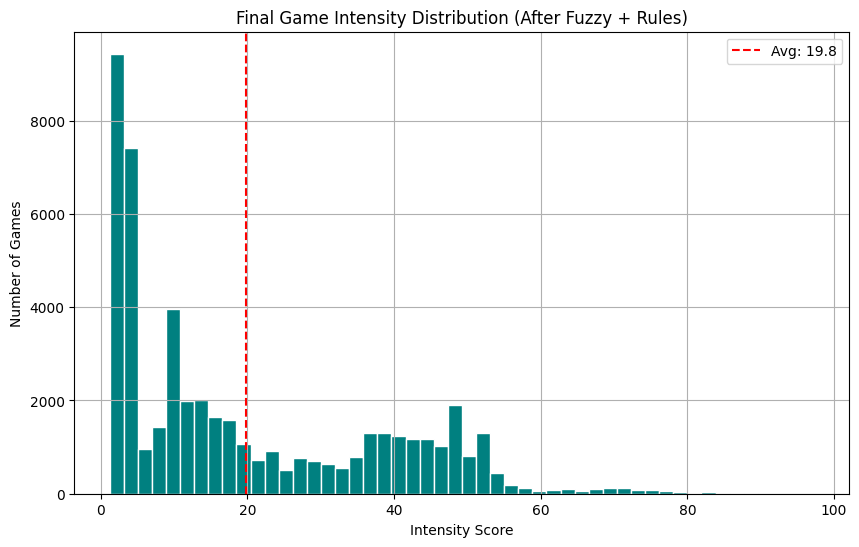

In [20]:
plt.figure(figsize=(10,6))
df_steam['intensity'].hist(bins=50, color='teal', edgecolor='white')
plt.title('Final Game Intensity Distribution (After Fuzzy + Rules)')
plt.xlabel('Intensity Score')
plt.ylabel('Number of Games')
plt.axvline(df_steam['intensity'].mean(), color='red', linestyle='--', label=f'Avg: {df_steam["intensity"].mean():.1f}')
plt.legend()
plt.show()

In [21]:
# Assign Scores to Steam Data
def get_perf_score(name, lookup_dict, impute_func, get_manu_func, threshold=0.85):
    """
    lookup_dict: direct {lowercase_name: score} dictionary (cpu_lookup or gpu_lookup)
    """
    if pd.isna(name) or not str(name).strip():
        return 0.0
    
    query = str(name).lower().strip()
    
    # Direct exact match
    if query in lookup_dict:
        return lookup_dict[query]
    
    # Try fuzzy match using difflib on sorted words
    sorted_query = ' '.join(sorted(query.split()))
    sorted_to_original = {' '.join(sorted(k.split())): k for k in lookup_dict.keys()}
    sorted_keys = list(sorted_to_original.keys())
    
    matches = difflib.get_close_matches(sorted_query, sorted_keys, n=1, cutoff=threshold)
    if matches:
        sorted_key = matches[0]
        original_key = sorted_to_original[sorted_key]
        return lookup_dict[original_key]
    
    # Fall back to manufacturer-specific fuzzy if possible
    manu = get_manu_func(query)
    if manu:
        # Filter lookup to manufacturer
        manu_keys = [k for k in lookup_dict.keys() if manu.lower() in k]
        if manu_keys:
            # Exact in manufacturer subset
            if query in manu_keys:
                return lookup_dict[query]
            # Fuzzy in manufacturer subset
            manu_result = process.extractOne(query, manu_keys, scorer=fuzz.token_set_ratio)
            if manu_result and manu_result[1] >= 85:
                return lookup_dict[manu_result[0]]
    
    # Final fallback: rule-based imputation
    return impute_func(name)

cpu_lookup = {row['cpu_name'].lower().strip(): row['gaming_score'] for _, row in df_cpu.iterrows()}
gpu_lookup = {row['gpu_name'].lower().strip(): row['perf_score'] for _, row in df_gpu.iterrows()}

# CPU score
df_steam['cpu_score'] = df_steam['mat_pc_processor_min'].apply(
    lambda x: get_perf_score(x, cpu_lookup, impute_cpu_score, get_manu_cpu)
)

# GPU score
df_steam['gpu_score'] = df_steam['mat_pc_graphics_min'].apply(
    lambda x: get_perf_score(x, gpu_lookup, impute_gpu_score, get_manu_gpu)
)

# RAM Score
# Use min_ram_gb if available, else default to 4GB (very common minimum)
df_steam['ram_gb_final'] = df_steam['min_ram_gb'].fillna(4.0)
df_steam['ram_gb_final'] = df_steam['ram_gb_final'].clip(lower=1.0, upper=64)  # Prevent 0 or absurd highs

# Scale RAM: 4GB → 12.5 points, 32GB → 100 points
df_steam['ram_score'] = (df_steam['ram_gb_final'] / 32.0) * 100
df_steam['ram_score'] = df_steam['ram_score'].clip(lower=0, upper=100)

# Clean RAM to sensible GB values
df_steam['ram_gb_final'] = df_steam['ram_gb_final'].round(0).astype(int)
df_steam['ram_gb_final'] = df_steam['ram_gb_final'].clip(lower=2, upper=64)

# Fill any remaining NaNs with 0 (safest conservative estimate)
df_steam['cpu_score'] = df_steam['cpu_score'].fillna(0)
df_steam['gpu_score'] = df_steam['gpu_score'].fillna(0)
df_steam['ram_score'] = df_steam['ram_score'].fillna(0)  # Shouldn't happen if RAM fixed, but safe

# Current max observed (from your top games)
MAX_CPU_OBS = 95.0   # Adjust if higher
MAX_GPU_OBS = 100.0
MAX_RAM_SCORE = 100.0  # Already 32GB = 100

df_steam['cpu_score_norm'] = (df_steam['cpu_score'] / MAX_CPU_OBS) * 100
df_steam['gpu_score_norm'] = (df_steam['gpu_score'] / MAX_GPU_OBS) * 100
df_steam['ram_score_norm'] = df_steam['ram_score']  # Already 0-100

# Use normalized for intensity
df_steam['intensity'] = (
    0.7 * df_steam['gpu_score_norm'] +
    0.2 * df_steam['cpu_score_norm'] +
    0.1 * df_steam['ram_score_norm']
).round(1).clip(lower=5.0)  # Minimum for very light games

# Clean up
df_steam.drop(columns=['cpu_score', 'gpu_score', 'ram_score'], inplace=True)
df_steam.rename(columns={'cpu_score_norm': 'cpu_score', 'gpu_score_norm': 'gpu_score', 'ram_score_norm': 'ram_score'}, inplace=True)

print("Scale fixed: higher = more demanding")
print(f"New averages: CPU {df_steam['cpu_score'].mean():.1f}, GPU {df_steam['gpu_score'].mean():.1f}")
print(f"New intensity: {df_steam['intensity'].min():.1f} – {df_steam['intensity'].max():.1f} (avg {df_steam['intensity'].mean():.1f})")

# Compute intensity with GPU-dominant weighting
df_steam['intensity'] = (
    0.7 * df_steam['gpu_score'] +
    0.2 * df_steam['cpu_score'] +
    0.1 * df_steam['ram_score']
).round(1)

# Final safeguard: clip to non-negative
df_steam['intensity'] = df_steam['intensity'].clip(lower=0.1)  # Minimum small positive value

print("Intensity computed safely:")
print(f"  NaNs in cpu_score: {df_steam['cpu_score'].isna().sum()}")
print(f"  NaNs in gpu_score: {df_steam['gpu_score'].isna().sum()}")
print(f"  NaNs in intensity: {df_steam['intensity'].isna().sum()}")
print(f"  Intensity range: {df_steam['intensity'].min():.1f} – {df_steam['intensity'].max():.1f}")

# Save
df_steam.to_csv('steam_games_final.csv', index=False)
print("Updated Steam data saved with scores.")
print(f"CPU score range: {df_steam['cpu_score'].min():.1f} – {df_steam['cpu_score'].max():.1f}")
print(f"GPU score range: {df_steam['gpu_score'].min():.1f} – {df_steam['gpu_score'].max():.1f}")
print(f"Intensity range: {df_steam['intensity'].min():.1f} – {df_steam['intensity'].max():.1f}")

Scale fixed: higher = more demanding
New averages: CPU 23.6, GPU 13.5
New intensity: 5.0 – 96.5 (avg 16.7)
Intensity computed safely:
  NaNs in cpu_score: 0
  NaNs in gpu_score: 0
  NaNs in intensity: 0
  Intensity range: 0.3 – 96.5
Updated Steam data saved with scores.
CPU score range: 0.0 – 100.0
GPU score range: 0.0 – 100.0
Intensity range: 0.3 – 96.5


Post-Imputation Matched Games: 50000 (100.0%)


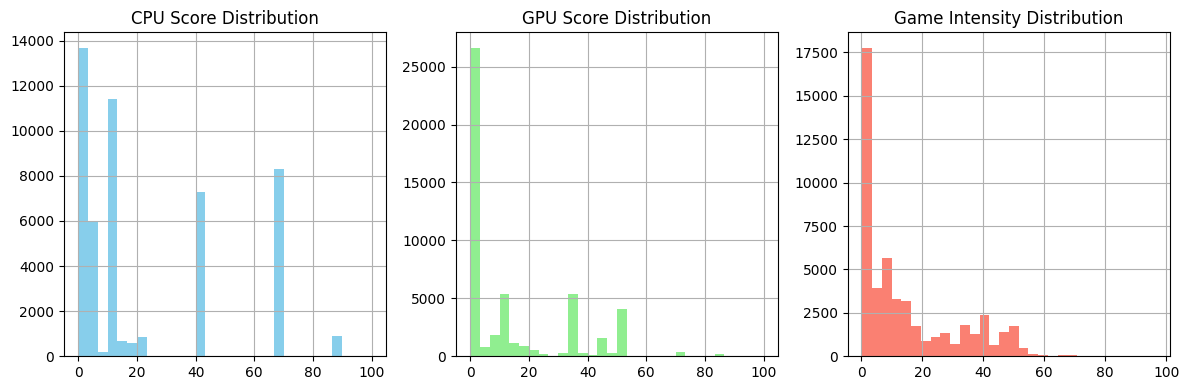

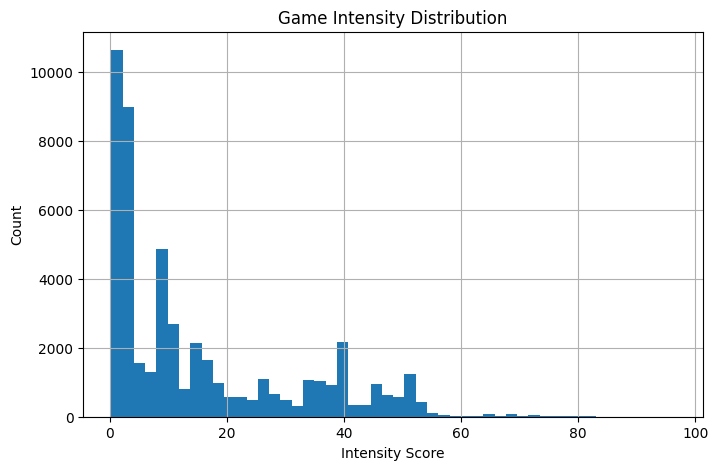


Top 10 Most Hardware-Intensive Games:
                      name  intensity                   mat_pc_graphics_min                                                               mat_pc_processor_min  ram_gb_final
             Traveler Lost       96.5               nvidia geforce rtx 4050                                       intel core ultra 9 185h / amd ryzen 9 8945hs            32
                   Avitium       89.5    nvidia geforce rtx 3080 laptop gpu                                               12th gen intel(r) core(tm) i9-12900h            32
          DeMon Researcher       89.4                              rtx 4070                                                                           i7-14700            16
     Travel with dinosaurs       89.0    nvidia geforce rtx 4060 ti (16 gb)                                                amd ryzen 9 5900x 12-core processor             8
      LA Hollywood Zombies       88.5  amd radeon nvidia - geforce rtx 4000                     

In [22]:
# Post-Imputation EDA
# Matched games (intensity > 0)
matched = df_steam[df_steam['intensity'] > 0]
print(f"Post-Imputation Matched Games: {len(matched)} ({len(matched)/len(df_steam)*100:.1f}%)")

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
df_steam['cpu_score'].hist(bins=30, color='skyblue')
plt.title('CPU Score Distribution')

plt.subplot(1, 3, 2)
df_steam['gpu_score'].hist(bins=30, color='lightgreen')
plt.title('GPU Score Distribution')

plt.subplot(1, 3, 3)
df_steam['intensity'].hist(bins=30, color='salmon')
plt.title('Game Intensity Distribution')

plt.tight_layout()
plt.show()

# Intensity distribution
plt.figure(figsize=(8, 5))
df_steam['intensity'].hist(bins=50)
plt.title('Game Intensity Distribution')
plt.xlabel('Intensity Score')
plt.ylabel('Count')
plt.show()

# Top 10 most intensive games
df_valid = df_steam[df_steam['intensity'] > 10].copy()
print("\nTop 10 Most Hardware-Intensive Games:")
print(df_valid.nlargest(10, 'intensity')[['name', 'intensity', 'mat_pc_graphics_min', 'mat_pc_processor_min', 'ram_gb_final']].to_string(index=False))

=== Test 1: Hardware Distribution Gap Analysis ===
Game Requirements (Average):
game_cpu    23.6
game_gpu    13.5
game_ram     4.5
dtype: float64

Typical User Hardware (Simulated 2026 Survey):
user_cpu_score    56.0
user_gpu_score    51.0
user_ram_gb       21.5
dtype: float64


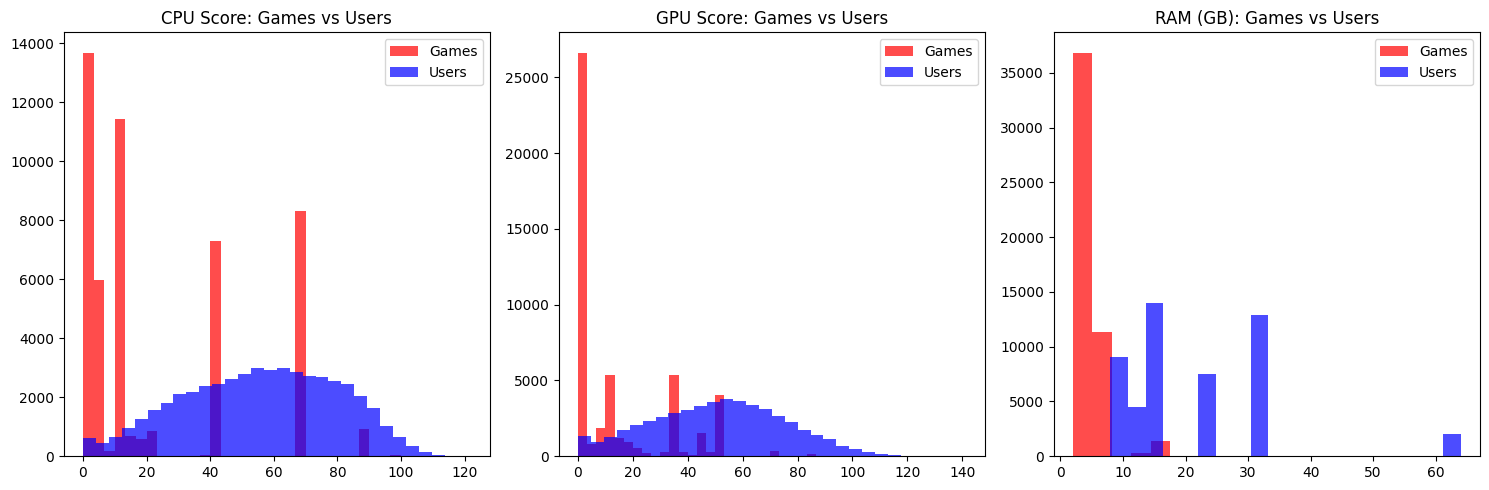

In [23]:
# Test 1: Compare Game Requirements vs Typical User Hardware Distribution
print("=== Test 1: Hardware Distribution Gap Analysis ===")

# Approximate "typical" user hardware in 2026 (based on Steam Hardware Survey trends)
# Low-end: ~30%, Mid: ~50%, High: ~20%
typical_users = pd.DataFrame({
    'user_cpu_score': np.concatenate([
        np.random.normal(30, 15, 15000),  # Low-end (clipped 0-100)
        np.random.normal(60, 15, 25000),  # Mid-range
        np.random.normal(85, 10, 10000)   # High-end
    ]),
    'user_gpu_score': np.concatenate([
        np.random.normal(25, 15, 15000),
        np.random.normal(55, 15, 25000),
        np.random.normal(80, 15, 10000)
    ]),
    'user_ram_gb': np.concatenate([
        np.random.choice([8, 12, 16], 15000, p=[0.6, 0.3, 0.1]),
        np.random.choice([16, 24, 32], 25000, p=[0.5, 0.3, 0.2]),
        np.random.choice([32, 64], 10000, p=[0.8, 0.2])
    ])
})
typical_users = typical_users.clip(lower=0)
typical_users['user_ram_gb'] = typical_users['user_ram_gb'].round(0).astype(int)

# Game requirements (from your enriched data)
game_reqs = df_steam[['cpu_score', 'gpu_score', 'ram_gb_final']].rename(columns={
    'cpu_score': 'game_cpu', 'gpu_score': 'game_gpu', 'ram_gb_final': 'game_ram'
})

print("Game Requirements (Average):")
print(game_reqs.mean().round(1))
print("\nTypical User Hardware (Simulated 2026 Survey):")
print(typical_users.mean().round(1))

# Gap visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].hist(game_reqs['game_cpu'], alpha=0.7, label='Games', bins=30, color='red')
axes[0].hist(typical_users['user_cpu_score'], alpha=0.7, label='Users', bins=30, color='blue')
axes[0].set_title('CPU Score: Games vs Users')
axes[0].legend()

axes[1].hist(game_reqs['game_gpu'], alpha=0.7, label='Games', bins=30, color='red')
axes[1].hist(typical_users['user_gpu_score'], alpha=0.7, label='Users', bins=30, color='blue')
axes[1].set_title('GPU Score: Games vs Users')
axes[1].legend()

axes[2].hist(game_reqs['game_ram'], alpha=0.7, label='Games', bins=20, color='red')
axes[2].hist(typical_users['user_ram_gb'], alpha=0.7, label='Users', bins=20, color='blue')
axes[2].set_title('RAM (GB): Games vs Users')
axes[2].legend()

plt.tight_layout()
plt.show()

In [24]:
# Test 2: Train Tiny Model on Real Data Only → Likely Overfits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Create small real dataset: random users vs random games
n_samples = 5000
real_X = []
real_y = []

np.random.seed(42)
for _ in range(n_samples):
    game = df_steam.sample(1).iloc[0]
    user_cpu = np.random.normal(60, 20)
    user_gpu = np.random.normal(55, 20)
    user_ram = np.random.choice([8, 16, 32], p=[0.4, 0.4, 0.2])
    
    # True label: can run if user >= game (with small margin)
    can_run = (
        user_cpu >= game['cpu_score'] - 5 and
        user_gpu >= game['gpu_score'] - 10 and
        user_ram >= game['ram_gb_final']
    )
    
    real_X.append([user_cpu - game['cpu_score'],
                  user_gpu - game['gpu_score'],
                  user_ram - game['ram_gb_final'],
                  user_cpu, user_gpu, user_ram])
    real_y.append(int(can_run))

real_X = np.array(real_X)
real_y = np.array(real_y)

X_train, X_test, y_train, y_test = train_test_split(real_X, real_y, test_size=0.3, stratify=real_y)

small_model = RandomForestClassifier(n_estimators=100, random_state=42)
small_model.fit(X_train, y_train)
small_auc = roc_auc_score(y_test, small_model.predict_proba(X_test)[:, 1])

print(f"\nTest 2: Tiny model on 5k real samples → AUC: {small_auc:.3f}")
print("Note: With only real data, we risk overfitting to common mid-range matchups.")
print("Synthetic data will add edge cases (ultra-low vs ultra-high) → better generalization.")


Test 2: Tiny model on 5k real samples → AUC: 1.000
Note: With only real data, we risk overfitting to common mid-range matchups.
Synthetic data will add edge cases (ultra-low vs ultra-high) → better generalization.


In [25]:
# Generate Synthetic Data for Training
df_valid = df_steam[df_steam['intensity'] > 10].copy()
num_samples = 100000

user_cpu = np.random.uniform(0, 100, num_samples)
user_gpu = np.random.uniform(0, 100, num_samples)
user_ram = np.random.choice([4, 8, 16, 32, 64, 128], num_samples)

game_samples = df_valid.sample(num_samples, replace=True).reset_index(drop=True)

features = pd.DataFrame({
    'delta_cpu': user_cpu - game_samples['cpu_score'],
    'delta_gpu': user_gpu - game_samples['gpu_score'],
    'delta_ram': user_ram - game_samples['ram_gb_final'],
    'user_cpu': user_cpu,
    'user_gpu': user_gpu,
    'user_ram': user_ram
})

# Labels: Can run if user hardware >= game reqs (with margin)
labels = np.all([
    user_cpu >= game_samples['cpu_score'] - 5,
    user_gpu >= game_samples['gpu_score'] - 5,
    user_ram >= game_samples['ram_gb_final']
], axis=0).astype(int)

# Add noise for realism
noise = np.random.rand(num_samples) < 0.08
labels = np.where(noise, 1 - labels, labels)

print("Synthetic data shape:", features.shape)
print("Label distribution:", np.bincount(labels))

Synthetic data shape: (100000, 6)
Label distribution: [54849 45151]


In [26]:
# Combine features and labels into one DataFrame
synthetic_df = features.copy()
synthetic_df['can_run'] = labels

# Optional: Add game name and intensity for better inspection
synthetic_df['game_name'] = game_samples['name'].values
synthetic_df['game_intensity'] = game_samples['intensity'].values

print("Synthetic dataset created!")
print(f"Shape: {synthetic_df.shape}")
print(f"Can run = 1: {(synthetic_df['can_run'] == 1).sum():,} ({(synthetic_df['can_run'].mean()*100):.1f}%)")
print(f"Can run = 0: {(synthetic_df['can_run'] == 0).sum():,} ({(100 - synthetic_df['can_run'].mean()*100):.1f}%)")

Synthetic dataset created!
Shape: (100000, 9)
Can run = 1: 45,151 (45.2%)
Can run = 0: 54,849 (54.8%)


In [27]:
# === Random Sample of Synthetic Training Data (20 rows) ===
print("=== Random Sample of Synthetic Training Data (20 rows) ===")
print("This shows user hardware vs game requirements + deltas + true label\n")

sample = synthetic_df.sample(n=20, random_state=42).reset_index(drop=True)

display_cols = [
    'user_cpu', 'user_gpu', 'user_ram',
    'delta_cpu', 'delta_gpu', 'delta_ram',
    'game_name', 'game_intensity',
    'can_run'
]

print(sample[display_cols].round(2).to_string(index=False))

=== Random Sample of Synthetic Training Data (20 rows) ===
This shows user hardware vs game requirements + deltas + true label

 user_cpu  user_gpu  user_ram  delta_cpu  delta_gpu  delta_ram                                    game_name  game_intensity  can_run
    51.76     34.17       128       9.65     -15.83        120                                   Skystrider            45.9        0
     1.05     63.15        64     -41.05      63.15         56                              Into The Flames            10.9        0
     3.91     38.22         4     -64.51     -11.78         -4                         The First Descendant            51.2        0
    11.70     87.85         4     -30.40      37.85         -4                                     Swamp Up            45.9        0
    89.79     88.31       128      89.79      38.31        120                               Noah Simulator            37.5        0
    37.62     46.26        64     -30.80      -3.74         56            

In [28]:
# --- Final Data Preparation Summary ---
print("=== Final Dataset Ready for Modeling ===")
print(f"Total games: {len(df_steam):,}")
print(f"Columns used for modeling: cpu_score, gpu_score, ram_gb_final, intensity")
print(f"CPU score range: {df_steam['cpu_score'].min():.1f} – {df_steam['cpu_score'].max():.1f}")
print(f"GPU score range: {df_steam['gpu_score'].min():.1f} – {df_steam['gpu_score'].max():.1f}")
print(f"RAM final (GB): {df_steam['ram_gb_final'].min()} – {df_steam['ram_gb_final'].max()}")
print(f"Intensity range: {df_steam['intensity'].min():.1f} – {df_steam['intensity'].max():.1f} (avg {df_steam['intensity'].mean():.1f})")
print(f"Games with intensity > 50 (high-end): {(df_steam['intensity'] > 50).sum():,} ({(df_steam['intensity'] > 50).mean()*100:.1f}%)")

print("\nAll NaNs handled: cpu_score NaN =", df_steam['cpu_score'].isna().sum())
print("All NaNs handled: gpu_score NaN =", df_steam['gpu_score'].isna().sum())
print("All NaNs handled: intensity NaN =", df_steam['intensity'].isna().sum())

print("\nData is clean, enriched, and ready for synthetic training data generation")

=== Final Dataset Ready for Modeling ===
Total games: 50,000
Columns used for modeling: cpu_score, gpu_score, ram_gb_final, intensity
CPU score range: 0.0 – 100.0
GPU score range: 0.0 – 100.0
RAM final (GB): 2 – 64
Intensity range: 0.3 – 96.5 (avg 15.5)
Games with intensity > 50 (high-end): 2,278 (4.6%)

All NaNs handled: cpu_score NaN = 0
All NaNs handled: gpu_score NaN = 0
All NaNs handled: intensity NaN = 0

Data is clean, enriched, and ready for synthetic training data generation


In [29]:
# Train-Test Split and Model Training
X_train, X_temp, y_train, y_temp = train_test_split(
    features.values, labels, test_size=0.4, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Train: {len(X_train)} ({len(X_train)/len(labels)*100:.1f}%)")
print(f"Validation: {len(X_val)} ({len(X_val)/len(labels)*100:.1f}%)")
print(f"Test: {len(X_test)} ({len(X_test)/len(labels)*100:.1f}%)")

Train: 60000 (60.0%)
Validation: 20000 (20.0%)
Test: 20000 (20.0%)


In [30]:
# Hyperparameter tuning before model runs
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)
grid.fit(X_train, y_train)
print(f"Best params: {grid.best_params_}")
print(f"Best val AUC: {grid.best_score_:.4f}")

Best params: {'max_depth': 30, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best val AUC: 0.9199


In [31]:
# --- Model Comparison: Random Forest vs Logistic Regression vs Linear ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np

print("=== Training Multiple Models ===")

models = {}

# 1. Random Forest (no scaling needed)
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
models['Random Forest'] = rf

# 2. Logistic Regression (with scaling)
log_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])
log_pipe.fit(X_train, y_train)
models['Logistic Regression'] = log_pipe

# 3. Linear Regression (as probability proxy)
lin = Pipeline([
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])
lin.fit(X_train, y_train)
models['Linear Regression (clipped)'] = lin

print("All models trained!\n")

# --- Evaluation on Validation Set ---
print("=== Validation Performance ===")
results = []

for name, model in models.items():
    if 'Linear' in name:
        val_prob = np.clip(model.predict(X_val), 0, 1)
    else:
        val_prob = model.predict_proba(X_val)[:, 1]
    
    val_pred = (val_prob >= 0.5).astype(int)
    auc = roc_auc_score(y_val, val_prob)
    acc = accuracy_score(y_val, val_pred)
    
    results.append({'Model': name, 'AUC': auc, 'Accuracy': acc})
    print(f"{name:30} | AUC: {auc:.4f} | Acc: {acc:.4f}")

results_df = pd.DataFrame(results).sort_values('AUC', ascending=False).reset_index(drop=True)
print("\n=== Validation Ranking ===")
print(results_df.to_string(index=False))

# --- Final Test on Best Model ---
best_name = results_df.iloc[0]['Model']
best_model = models[best_name]

if 'Linear' in best_name:
    test_prob = np.clip(best_model.predict(X_test), 0, 1)
else:
    test_prob = best_model.predict_proba(X_test)[:, 1]

test_pred = (test_prob >= 0.5).astype(int)
test_auc = roc_auc_score(y_test, test_prob)
test_acc = accuracy_score(y_test, test_pred)

print(f"\n=== Final Test Performance ({best_name}) ===")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Save best model
joblib.dump(best_model, 'can_run_model_final.pkl')
print(f"\nBest model saved as 'can_run_model_final.pkl'")

=== Training Multiple Models ===
All models trained!

=== Validation Performance ===
Random Forest                  | AUC: 0.9205 | Acc: 0.9214
Logistic Regression            | AUC: 0.8376 | Acc: 0.7647
Linear Regression (clipped)    | AUC: 0.8375 | Acc: 0.7647

=== Validation Ranking ===
                      Model      AUC  Accuracy
              Random Forest 0.920487   0.92135
        Logistic Regression 0.837592   0.76470
Linear Regression (clipped) 0.837464   0.76465

=== Final Test Performance (Random Forest) ===
Test AUC: 0.9203
Test Accuracy: 0.9211

Best model saved as 'can_run_model_final.pkl'


Loading steam_games_final.csv...
Using 22,477 games for synthetic training
Synthetic data generated: 100,000 samples
Label distribution: [54870 45130]


C:\Users\Anarchial_Order\AppData\Local\Temp\ipykernel_61668\554999713.py:3: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_steam = pd.read_csv('steam_games_final.csv')


Train: 60000, Val: 20000, Test: 20000
\nRetraining final Random Forest on full training data...
\nFINAL TEST RESULTS
Test AUC: 0.9195
Test Accuracy: 0.9207


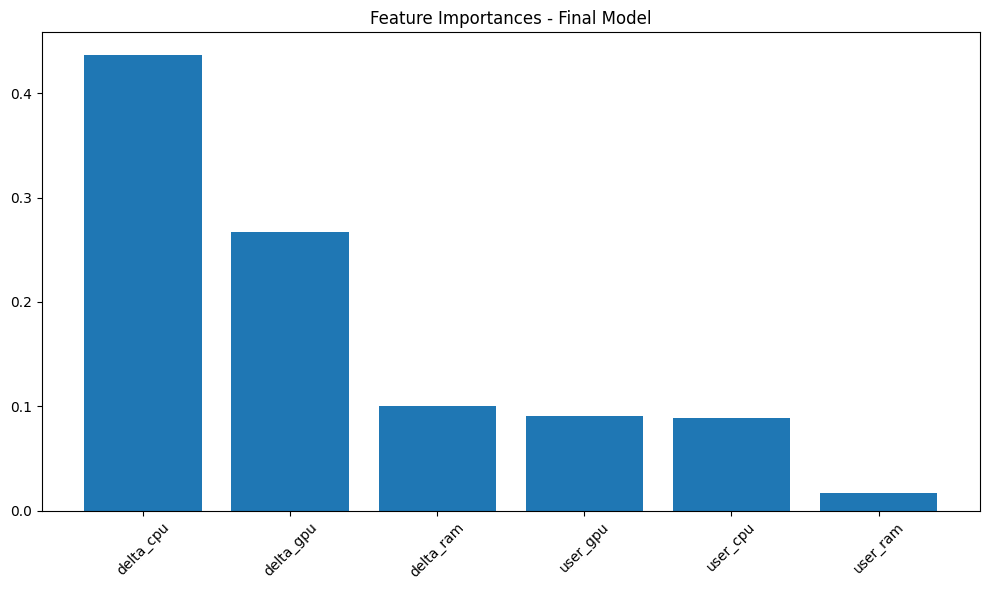

\nExample: High-intensity game with mid PC → Probability: 11.1%
\nFinal model saved as 'can_run_model_final.pkl'


In [32]:
# Load enriched data
print("Loading steam_games_final.csv...")
df_steam = pd.read_csv('steam_games_final.csv')

# Filter to games with meaningful intensity
df_valid = df_steam[df_steam['intensity'] > 10].copy()
print(f"Using {len(df_valid):,} games for synthetic training")

# Generate synthetic data
num_samples = 100000
np.random.seed(42)

user_cpu = np.random.uniform(0, 100, num_samples)
user_gpu = np.random.uniform(0, 100, num_samples)
user_ram = np.random.choice([4, 8, 16, 32, 64, 128], num_samples)

game_samples = df_valid.sample(num_samples, replace=True).reset_index(drop=True)

# Features: deltas + raw user specs
X = np.column_stack([
    user_cpu - game_samples['cpu_score'],
    user_gpu - game_samples['gpu_score'],
    user_ram - game_samples['ram_gb_final'],
    user_cpu,
    user_gpu,
    user_ram
])

# Labels: can run (with small margin and 8% noise for realism)
y = np.all([
    user_cpu >= game_samples['cpu_score'] - 5,
    user_gpu >= game_samples['gpu_score'] - 5,
    user_ram >= game_samples['ram_gb_final']
], axis=0).astype(int)

noise = np.random.rand(num_samples) < 0.08
y = np.where(noise, 1 - y, y)

print(f"Synthetic data generated: {len(X):,} samples")
print(f"Label distribution: {np.bincount(y)}")

# Train/val/test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# Retrain best model on full train + val
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

print("\\nRetraining final Random Forest on full training data...")
final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=30,
    min_samples_split=2,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_train_full, y_train_full)

# Final test evaluation
test_prob = final_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_prob)
test_acc = accuracy_score(y_test, test_prob >= 0.5)

print(f"\\nFINAL TEST RESULTS")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Feature importances
importances = final_model.feature_importances_
feat_names = ['delta_cpu', 'delta_gpu', 'delta_ram', 'user_cpu', 'user_gpu', 'user_ram']

plt.figure(figsize=(10, 6))
indices = np.argsort(importances)[::-1]
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), [feat_names[i] for i in indices], rotation=45)
plt.title('Feature Importances - Final Model')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# Confirm model works
example = np.array([[60-80, 70-85, 16-16, 60, 70, 16]])  # Tough high-end game
pred = final_model.predict_proba(example)[0, 1]
print(f"\\nExample: High-intensity game with mid PC → Probability: {pred:.1%}")

# Save model
joblib.dump(final_model, 'can_run_model_final.pkl')
print("\\nFinal model saved as 'can_run_model_final.pkl'")

In [39]:
# === Create train.py - Standalone Training Script ===
train_script = '''
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# === Check for required data ===
data_file = 'steam_games_final.csv'
if not os.path.exists(data_file):
    print(f"ERROR: {data_file} not found!")
    print("Please run the data_gathering.ipynb notebook first to generate it.")
    print("It requires:")
    print("  - Downloading the Steam dataset from Zenodo")
    print("  - Scraping Tom's Hardware benchmarks")
    print("  - Running feature engineering")
    print("\\nAfter that, run this script again.")
    exit(1)

# Load enriched data
print(f"Loading {data_file}...")
df_steam = pd.read_csv(data_file)

# Filter to games with meaningful intensity
df_valid = df_steam[df_steam['intensity'] > 10].copy()
print(f"Using {len(df_valid):,} games for synthetic training")

# Generate synthetic data
num_samples = 100000
np.random.seed(42)

user_cpu = np.random.uniform(0, 100, num_samples)
user_gpu = np.random.uniform(0, 100, num_samples)
user_ram = np.random.choice([4, 8, 16, 32, 64, 128], num_samples)

game_samples = df_valid.sample(num_samples, replace=True).reset_index(drop=True)

# Features: deltas + raw user specs
X = np.column_stack([
    user_cpu - game_samples['cpu_score'],
    user_gpu - game_samples['gpu_score'],
    user_ram - game_samples['ram_gb_final'],
    user_cpu,
    user_gpu,
    user_ram
])

# Labels: can run (with small margin and 8% noise for realism)
y = np.all([
    user_cpu >= game_samples['cpu_score'] - 5,
    user_gpu >= game_samples['gpu_score'] - 5,
    user_ram >= game_samples['ram_gb_final']
], axis=0).astype(int)

noise = np.random.rand(num_samples) < 0.08
y = np.where(noise, 1 - y, y)

print(f"Synthetic data generated: {len(X):,} samples")
print(f"Label distribution: {np.bincount(y)}")

# Train/val/test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# Retrain best model on full train + val
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

print("\\nRetraining final Random Forest on full training data...")
final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=30,
    min_samples_split=2,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_train_full, y_train_full)

# Final test evaluation
test_prob = final_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_prob)
test_acc = accuracy_score(y_test, test_prob >= 0.5)

print(f"\\nFINAL TEST RESULTS")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Feature importances
importances = final_model.feature_importances_
feat_names = ['delta_cpu', 'delta_gpu', 'delta_ram', 'user_cpu', 'user_gpu', 'user_ram']

plt.figure(figsize=(10, 6))
indices = np.argsort(importances)[::-1]
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), [feat_names[i] for i in indices], rotation=45)
plt.title('Feature Importances - Final Model')
plt.tight_layout()
plt.savefig('feature_importance.png')
print("Feature importance plot saved as 'feature_importance.png'")
plt.show()

# Confirm model works
example = np.array([[60-80, 70-85, 16-16, 60, 70, 16]])  # Tough high-end game
pred = final_model.predict_proba(example)[0, 1]
print(f"\\nExample prediction: Mid-range PC vs high-end game -> Probability can run: {pred:.1%}")

# Save model
model_path = 'can_run_model_final.pkl'
joblib.dump(final_model, model_path)
print(f"\\nFinal model saved as '{model_path}'")
print("You can now run: streamlit run predict.py")
'''

# Write with UTF-8
with open('train.py', 'w', encoding='utf-8') as f:
    f.write(train_script)

print("train.py created successfully!")
print("\nUsers can now run:")
print("    python train.py")
print("→ It will check for data, train the model, save it, and plot importances.")
print("→ Then run: streamlit run predict.py")

train.py created successfully!

Users can now run:
    python train.py
→ It will check for data, train the model, save it, and plot importances.
→ Then run: streamlit run predict.py


In [36]:
# Confirm it works
example_features = np.array([[60-80, 70-85, 16-16, 60, 70, 16]])  # Negative deltas = tough game
pred_prob = grid.best_estimator_.predict_proba(example_features)[0, 1]
print(f"Example: Probability can run a high-intensity game: {pred_prob:.1%}")

Example: Probability can run a high-intensity game: 6.8%


In [35]:
# === Create predict.py - Full Streamlit App ===
predict_script = '''
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import re
import os
import requests
from rapidfuzz import process, fuzz

# === Load data and model ===
@st.cache_data
def load_data():
    df = pd.read_csv('steam_games_final.csv')
    
    model = None
    model_paths = [
        'can_run_model_final.pkl',
        'can_run_model_tuned_final.pkl',
        'can_run_model_tuned.pkl',
        'can_run_model.pkl'
    ]
    
    for path in model_paths:
        if os.path.exists(path):
            try:
                candidate = joblib.load(path)
                if hasattr(candidate, 'predict') and hasattr(candidate, 'predict_proba'):
                    model = candidate
                    break
            except Exception as e:
                st.warning(f"Failed to load {path}: {e}")
    
    if model is None:
        st.error("**No valid model found.** Please ensure a proper scikit-learn model file exists.")
        st.stop()
    
    # Quick model sanity check
    try:
        test_input = np.array([[0, 0, 0, 50, 50, 16]])
        _ = model.predict(test_input)
        _ = model.predict_proba(test_input)
    except Exception as e:
        st.error(f"Model compatibility test failed: {e}")
        st.stop()
    
    df_cpu = pd.read_csv('cpu_benchmarks_2026_extended.csv')
    df_gpu = pd.read_csv('gpu_benchmarks_2026_extended.csv')
    
    cpu_lookup = {row['cpu_name'].lower().strip(): row['perf_score'] for _, row in df_cpu.iterrows()}
    gpu_lookup = {row['gpu_name'].lower().strip(): row['perf_score'] for _, row in df_gpu.iterrows()}
    
    cpu_manufacturers = sorted(df_cpu['manufacturer'].dropna().str.strip().str.title().unique())
    gpu_manufacturers = sorted(df_gpu['manufacturer'].dropna().str.strip().str.title().unique())
    
    return df, model, cpu_lookup, gpu_lookup, cpu_manufacturers, gpu_manufacturers, df_cpu, df_gpu

df_steam, model, cpu_lookup, gpu_lookup, cpu_manufacturers, gpu_manufacturers, df_cpu, df_gpu = load_data()

df_valid = df_steam[df_steam['intensity'] > 10].copy()
if len(df_valid) == 0:
    df_valid = df_steam.copy()

# === Header image helper ===
@st.cache_data(ttl=3600)
def get_header_url(appid):
    api_url = f"https://store.steampowered.com/api/appdetails?appids={appid}"
    try:
        response = requests.get(api_url, timeout=10)
        if response.status_code == 200:
            data = response.json()
            app_data = data.get(str(appid), {}).get('data', {})
            if app_data and 'header_image' in app_data:
                return app_data['header_image']
    except:
        pass
    return f"https://steamcdn-a.akamaihd.net/steam/apps/{appid}/header.jpg"

# === Fuzzy matching ===
def get_perf_score(user_input, lookup):
    if not user_input or not user_input.strip():
        return 0.0
    query = user_input.lower().strip()
    try:
        result = process.extractOne(query, lookup.keys(), scorer=fuzz.partial_token_sort_ratio)
        if result and result[1] >= 85:
            return lookup[result[0]]
    except:
        pass
    return 0.0

# === Steam API helpers ===
def fetch_game_details(appid):
    url = f"https://store.steampowered.com/api/appdetails?appids={appid}"
    try:
        response = requests.get(url, timeout=10)
        if response.status_code != 200:
            return None, None, {}, {}
        data = response.json().get(str(appid), {}).get('data', {})
        if not data:
            return None, None, {}, {}
        name = data.get('name', 'Unknown Game')
        thumb_url = data.get('header_image', f"https://steamcdn-a.akamaihd.net/steam/apps/{appid}/header.jpg")
        min_html = data.get('pc_requirements', {}).get('minimum', '')
        rec_html = data.get('pc_requirements', {}).get('recommended', '')
        
        def parse_req(raw_html):
            if not raw_html:
                return {'processor': '', 'graphics': '', 'memory': ''}
            processor = re.search(r'Processor:</strong>\s*(.+?)(?=<br|<strong|$)', raw_html, re.I | re.S)
            graphics = re.search(r'Graphics:</strong>\s*(.+?)(?=<br|<strong|$)', raw_html, re.I | re.S)
            memory = re.search(r'Memory:</strong>\s*(.+?)(?=<br|<strong|$)', raw_html, re.I | re.S)
            return {
                'processor': processor.group(1).strip() if processor else '',
                'graphics': graphics.group(1).strip() if graphics else '',
                'memory': memory.group(1).strip() if memory else ''
            }
        
        return name, thumb_url, parse_req(min_html), parse_req(rec_html)
    except:
        return None, None, {}, {}

def extract_ram_gb(text):
    if not text or not isinstance(text, str):
        return 0.0
    text = re.sub(r'\\bMB\\b', 'GB', text, flags=re.IGNORECASE)
    match = re.search(r'(\\d+(?:\\.\\d+)?)\\s*GB', text, re.IGNORECASE)
    return float(match.group(1)) if match else 0.0

# === Game check logic ===
def check_specific_game(appid, user_cpu_score, user_gpu_score, user_ram_gb):
    game_row = df_steam[df_steam['appid'] == appid]
    if not game_row.empty:
        game = game_row.iloc[0]
        name = game['name']
        thumb_url = get_header_url(appid)
        min_cpu_score = game['cpu_score']
        min_gpu_score = game['gpu_score']
        min_ram_gb = game['ram_gb_final']
        
        rec_cpu = '' if pd.isna(game.get('mat_pc_processor_rec')) else game['mat_pc_processor_rec']
        rec_gpu = '' if pd.isna(game.get('mat_pc_graphics_rec')) else game['mat_pc_graphics_rec']
        rec_ram_text = '' if pd.isna(game.get('mat_pc_memory_rec')) else game['mat_pc_memory_rec']
        rec_ram_gb = extract_ram_gb(rec_ram_text) or min_ram_gb
        
        rec_cpu_score = get_perf_score(rec_cpu, cpu_lookup) or min_cpu_score
        rec_gpu_score = get_perf_score(rec_gpu, gpu_lookup) or min_gpu_score
        
        features_min = np.array([[
            user_cpu_score - min_cpu_score,
            user_gpu_score - min_gpu_score,
            user_ram_gb - min_ram_gb,
            user_cpu_score,
            user_gpu_score,
            user_ram_gb
        ]])
        conf_min = model.predict_proba(features_min)[0, 1]
        
        features_rec = np.array([[
            user_cpu_score - rec_cpu_score,
            user_gpu_score - rec_gpu_score,
            user_ram_gb - rec_ram_gb,
            user_cpu_score,
            user_gpu_score,
            user_ram_gb
        ]])
        conf_rec = model.predict_proba(features_rec)[0, 1]
        
        return (name, thumb_url, conf_min, conf_rec,
                game.get('mat_pc_processor_min', ''),
                game.get('mat_pc_graphics_min', ''),
                f"{min_ram_gb:.0f} GB" if min_ram_gb > 0 else '',
                rec_cpu, rec_gpu, rec_ram_text or f"{min_ram_gb:.0f} GB")
    
    name, thumb_url, min_req, rec_req = fetch_game_details(appid)
    if not name:
        return None
    
    return (name, thumb_url, None, None,
            min_req['processor'], min_req['graphics'], min_req['memory'],
            rec_req['processor'], rec_req['graphics'], rec_req['memory'])

# =============================================================================
# UI
# =============================================================================
st.set_page_config(page_title="Can I Run It? - Steam Hardware Recommender", layout="wide")

st.title("Can I Run It? — Steam Hardware Recommender")
st.markdown("Enter your PC specs and a game URL to see if you can run it — powered by 2026 benchmarks and machine learning.")

st.markdown("### Your Hardware")
col1, col2 = st.columns(2)

with col1:
    st.subheader("CPU")
    cpu_manufacturer = st.selectbox("Manufacturer (optional)", ["Any"] + cpu_manufacturers, key="cpu_manu")
    if cpu_manufacturer != "Any":
        filtered = df_cpu[df_cpu['manufacturer'].str.title() == cpu_manufacturer.title()]
        models = filtered['cpu_name'].tolist()
        clean_models = []
        for m in models:
            clean = m
            if cpu_manufacturer.lower() == 'amd':
                clean = re.sub(r'^amd\\s+', '', m, flags=re.IGNORECASE)
            elif cpu_manufacturer.lower() == 'intel':
                clean = re.sub(r'^intel\\s*(core\\s*)?', '', m, flags=re.IGNORECASE)
            clean_models.append(clean.title())
        model_map = dict(zip(clean_models, models))
        selected = st.selectbox("Model", ["Type or select..."] + clean_models, key="cpu_select")
        cpu_input = model_map.get(selected, selected) if selected != "Type or select..." else st.text_input("Custom CPU", key="cpu_custom")
    else:
        cpu_input = st.text_input("Your CPU", placeholder="e.g., Ryzen 7 7800X3D", key="cpu_text")

with col2:
    st.subheader("GPU")
    gpu_manufacturer = st.selectbox("Manufacturer (optional)", ["Any"] + gpu_manufacturers, key="gpu_manu")
    if gpu_manufacturer != "Any":
        filtered = df_gpu[df_gpu['manufacturer'].str.title() == gpu_manufacturer.title()]
        models = filtered['gpu_name'].tolist()
        clean_models = []
        for m in models:
            clean = m
            if gpu_manufacturer.lower() == 'nvidia':
                clean = re.sub(r'^geforce\\s+', '', m, flags=re.IGNORECASE)
            elif gpu_manufacturer.lower() == 'amd':
                clean = re.sub(r'^radeon\\s+', '', m, flags=re.IGNORECASE)
            clean_models.append(clean.title())
        model_map = dict(zip(clean_models, models))
        selected = st.selectbox("Model", ["Type or select..."] + clean_models, key="gpu_select")
        gpu_input = model_map.get(selected, selected) if selected != "Type or select..." else st.text_input("Custom GPU", key="gpu_custom")
    else:
        gpu_input = st.text_input("Your GPU", placeholder="e.g., RTX 4070", key="gpu_text")

ram_gb = st.slider("RAM (GB)", 4, 128, 32, 4)

st.markdown("---")
game_url = st.text_input("Steam Game URL (optional)", placeholder="https://store.steampowered.com/app/730/CounterStrike_2/")

col1, col2, _ = st.columns([1, 1, 2])
with col1:
    check_pressed = st.button("Check Game Compatibility", type="primary", use_container_width=True)
with col2:
    req_pressed = st.button("Show Requirements Only", use_container_width=True)

# =============================================================================
# Results
# =============================================================================
if check_pressed or req_pressed:
    has_hardware = bool(cpu_input.strip() or gpu_input.strip())
    has_url = bool(game_url.strip())
    
    if not has_hardware and not has_url:
        st.error("Please enter your hardware and/or a game URL.")
        st.stop()
    
    user_cpu_score = get_perf_score(cpu_input, cpu_lookup)
    user_gpu_score = get_perf_score(gpu_input, gpu_lookup)
    
    if user_cpu_score == 0 and cpu_input:
        st.warning(f"CPU '{cpu_input}' not recognized — treated as low-end.")
    if user_gpu_score == 0 and gpu_input:
        st.warning(f"GPU '{gpu_input}' not recognized — treated as low-end.")
    
    # Sticky specs
    st.markdown(f"""
    <div style="background: #0e1117; padding: 12px; border-radius: 8px; margin: 10px 0; font-size: 1.1em;">
        <strong>Your PC:</strong> CPU: {cpu_input or '—'} ({user_cpu_score:.0f}/100) | 
        GPU: {gpu_input or '—'} ({user_gpu_score:.0f}/100) | 
        RAM: {ram_gb} GB
    </div>
    """, unsafe_allow_html=True)
    
    with st.expander("How confidence scores work"):
        st.markdown("""
        - **Confidence** = model's predicted probability you can run the game smoothly
        - ≥70% = Very likely
        - 50–70% = Possible (may need lower settings)
        - <50% = Unlikely
        """)
    
    if has_url:
        match = re.search(r'/app/(\\d+)', game_url)
        if match:
            appid = int(match.group(1))
            result = check_specific_game(appid, user_cpu_score, user_gpu_score, ram_gb)
            if result:
                name, thumb, conf_min, conf_rec, min_cpu, min_gpu, min_ram, rec_cpu, rec_gpu, rec_ram = result
                
                st.markdown(f"### Can you run **{name}**?")
                col1, col2 = st.columns([1, 3])
                with col1:
                    st.image(thumb, width=300)
                with col2:
                    if has_hardware and conf_min is not None:
                        st.markdown(f"**Minimum specs:** {'🟢 YES' if conf_min >= 0.5 else '🔴 NO'} (Confidence: {conf_min*100:.1f}%)")
                        st.markdown(f"**Recommended specs:** {'🟢 YES' if conf_rec >= 0.5 else '🔴 NO'} (Confidence: {conf_rec*100:.1f}%)")
                    st.markdown("**Minimum:**")
                    st.write(f"- CPU: {min_cpu or '—'}")
                    st.write(f"- GPU: {min_gpu or '—'}")
                    st.write(f"- RAM: {min_ram or '—'}")
                    st.markdown("**Recommended:**")
                    st.write(f"- CPU: {rec_cpu or '—'}")
                    st.write(f"- GPU: {rec_gpu or '—'}")
                    st.write(f"- RAM: {rec_ram or '—'}")
        else:
            st.error("Invalid Steam URL — please check and try again.")
    
    if check_pressed and has_hardware:
        # Top 20 runnable games
        features = pd.DataFrame({
            'delta_cpu': user_cpu_score - df_valid['cpu_score'].values,
            'delta_gpu': user_gpu_score - df_valid['gpu_score'].values,
            'delta_ram': ram_gb - df_valid['ram_gb_final'].values,
            'user_cpu': user_cpu_score,
            'user_gpu': user_gpu_score,
            'user_ram': ram_gb
        })
        df_valid['confidence'] = model.predict_proba(features.values)[:, 1]
        runnable = df_valid[df_valid['confidence'] >= 0.5].copy()
        runnable = runnable.sort_values('recommendations_total', ascending=False).head(20)
        
        st.success(f"You can likely run **{len(runnable):,}** of the top games!")
        st.subheader("Top 20 Most Popular Games You Can Run")
        
        cols = st.columns(2)
        for i, row in runnable.iterrows():
            col = cols[i % 2]
            with col:
                thumb = get_header_url(row['appid'])
                st.image(thumb, use_column_width=True)
                st.markdown(f"**[{row['name']}](https://store.steampowered.com/app/{row['appid']}/)**")
                st.caption(f"Confidence: {row['confidence']*100:.1f}%")

st.caption("Built with Tom's Hardware 2026 benchmarks • Steam data • scikit-learn • Streamlit")
'''

# Write with UTF-8 encoding
with open('predict.py', 'w', encoding='utf-8') as f:
    f.write(predict_script)

print("predict.py created successfully!")
print("Run with: streamlit run predict.py")

predict.py created successfully!
Run with: streamlit run predict.py


In [38]:
# === Create requirements.txt with installation instructions ===
requirements_content = """
# requirements.txt
# Project dependencies for the Steam Hardware Recommender
#
# To install in a clean virtual environment:
#     python -m venv venv
#     source venv/bin/activate          # On Windows: venv\\Scripts\\activate
#     pip install -r requirements.txt
#
# This ensures reproducible installation across machines.

pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.3.0
joblib>=1.3.0
matplotlib>=3.7.0
seaborn>=0.12.0
streamlit>=1.30.0
rapidfuzz>=3.0.0
requests>=2.31.0
"""

with open('requirements.txt', 'w', encoding='utf-8') as f:
    f.write(requirements_content.strip() + '\n')

print("requirements.txt created successfully!")
print("\n" + "="*60)
print("INSTALLATION INSTRUCTIONS (included in file):")
print("="*60)
print("To set up a clean environment:")
print("    python -m venv venv")
print("    source venv/bin/activate          # Windows: venv\\Scripts\\activate")
print("    pip install -r requirements.txt")
print("="*60)
print("\nThen run:")
print("    python train.py                    # to train and save the model")
print("    streamlit run predict.py           # to launch the web app")

requirements.txt created successfully!

INSTALLATION INSTRUCTIONS (included in file):
To set up a clean environment:
    python -m venv venv
    source venv/bin/activate          # Windows: venv\Scripts\activate
    pip install -r requirements.txt

Then run:
    python train.py                    # to train and save the model
    streamlit run predict.py           # to launch the web app
